In [122]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr

import geopandas as gpd
from shapely.geometry import Point
from geopandas import GeoDataFrame
from geopy.distance import geodesic
from datetime import date, timedelta

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from collections import defaultdict

In [170]:
gridMET_avg_df = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/scripts/gridMET_avg.csv")

In [171]:
# Load daily gridMET data
gridMET_hz_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

# Identify meta and timeseries columns
meta_cols = ['id2', 'year', 'yield']
ts_cols = [col for col in gridMET_hz_data.columns if col not in meta_cols]

# Group columns by variable type
contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
            'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']
# contents = ['vpd', 'etr', 'erc', 'bi']

grouped_features = defaultdict(list)
for col in ts_cols:
    for prefix in contents:
        if col.startswith(prefix + '-'):
            grouped_features[prefix].append(col)

# Function to extract summary stats
def extract_summary_stats(df, columns, prefix):
    sub_df = df[columns]
    stats = pd.DataFrame(index=df.index)
    stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
    stats[f'{prefix}_std'] = sub_df.std(axis=1)
    stats[f'{prefix}_min'] = sub_df.min(axis=1)
    stats[f'{prefix}_max'] = sub_df.max(axis=1)
    stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
    stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
    stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
    stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
    stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
    return stats

# Extract summary features for each variable group
feature_stats_list = [extract_summary_stats(gridMET_hz_data, cols, prefix) for prefix, cols in grouped_features.items()]
features_reduced = pd.concat(feature_stats_list, axis=1)

# Add ID and year
features_reduced['id2'] = gridMET_hz_data['id2']
features_reduced['year'] = gridMET_hz_data['year']
features_reduced['yield'] = gridMET_hz_data['yield']

# Historical yield features
df_yield = gridMET_hz_data[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())

# Add trend projection
def add_yield_trend(group):
    proj = []
    for _, row in group.iterrows():
        past = group[group['year'] < row['year']]
        if len(past) >= 3:
            slope, intercept = np.polyfit(past['year'], past['yield'], 1)
            proj.append(slope * row['year'] + intercept)
        else:
            proj.append(np.nan)
    group['yield_trend_pred'] = proj
    return group

df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)

# Merge yield-based features with main features
gridMET_augmented = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')

# Rearranging columns
col_list = gridMET_augmented.columns
new_order = ['id2', 'year'] + [col for col in col_list if col not in ['id2', 'year', 'yield']] + ['yield']
gridMET_augmented = gridMET_augmented[new_order]

# Drop rows with missing values
gridMET_augmented = gridMET_augmented.dropna()
gridMET_augmented = gridMET_augmented.reset_index(drop = True)

/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_60099/1152536507.py:65: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)


In [172]:
gridMET_augmented.columns

Index(['id2', 'year', 'tmmx_mean', 'tmmx_std', 'tmmx_min', 'tmmx_max',
       'tmmx_25q', 'tmmx_50q', 'tmmx_75q', 'tmmx_skew',
       ...
       'th_skew', 'th_kurt', 'yield_prev_year', 'yield_5yr_mean', 'yield_min',
       'yield_max', 'yield_std', 'yield_mean', 'yield_trend_pred', 'yield'],
      dtype='object', length=154)

# Feature Importance

### Important Features Identified by Ridge Regression (2011 Prediction)

| **Feature**                                  | **Description**                                                    | **Importance** |
|----------------------------------------------|--------------------------------------------------------------------|----------------|
| `yield_mean`                                  | Mean historical yield                                             | **+13.68**     |
| `year`                                        | Calendar year                                                     | **+7.39**      |
| `yield_max`                                   | Maximum historical yield                                          | **+5.98**      |
| `tmmx_mean` *(Maximum Near-Surface Air Temperature)* | Average daily max temperature                              | **−4.74**      |
| `erc_mean` *(Energy Release Component)*       | Fire danger index representing fuel dryness and burn potential    | **−4.08**      |
| `rmax_mean` *(Maximum Near-Surface Relative Humidity)* | Average of daily maximum relative humidity               | **+3.53**      |


In [51]:
non_model_cols = ['yield']
X_all = gridMET_augmented.drop(columns=non_model_cols)
y_all = gridMET_augmented['yield']

train_mask = gridMET_augmented['year'] < 2011
test_mask = gridMET_augmented['year'] == 2011

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

model = Ridge(alpha=1000.0)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nYear 2011 Forecast Results:")
print(f"  R²: {r2:.4f}")
print(f"  RMSE: {rmse:.4f}")

feature_names = X_train_raw.columns
coefs = model.coef_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance (Ridge Coefficient)': coefs
}).sort_values(by='Importance (Ridge Coefficient)', key=np.abs, ascending=False)

print("\nTop Feature Importances (absolute value):")
print(feature_importance_df.head(15))


Year 2011 Forecast Results:
  R²: 0.5314
  RMSE: 22.8183

Top Feature Importances (absolute value):
             Feature  Importance (Ridge Coefficient)
23        yield_mean                       13.680684
1               year                        7.393950
21         yield_max                        5.982263
2          tmmx_mean                       -4.737551
9           erc_mean                       -4.082886
3          rmax_mean                        3.530919
17           th_mean                       -2.972986
22         yield_std                        2.769304
13        fm100_mean                        2.159038
8          srad_mean                       -2.139611
16         tmmn_mean                       -2.132925
20         yield_min                        2.083544
24  yield_trend_pred                        1.963926
11         rmin_mean                        1.835768
4            vs_mean                        1.722318


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# Ridge Regression

In [170]:
non_model_cols = ['yield'] ##'id2', 'year', 
X_all = gridMET_augmented.drop(columns=non_model_cols)
y_all = gridMET_augmented['yield']
years = gridMET_augmented['year'].values
unique_years = sorted(gridMET_augmented['year'].unique())

yearwise_metrics = []

for test_year in range(2010, 2019):  # 2010 to 2018
    train_mask = gridMET_augmented['year'] < test_year
    test_mask = gridMET_augmented['year'] == test_year

    X_train_raw = X_all[train_mask]
    y_train = y_all[train_mask]
    X_test_raw = X_all[test_mask]
    y_test = y_all[test_mask]
    
    if len(y_test) == 0 or len(y_train) == 0:
        continue

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    model = Ridge(alpha=1000.0)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    yearwise_metrics.append((test_year, r2, rmse))

    print(f"Year {test_year} Forecast Results:")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print()

print("=== Summary Metrics ===")
for year, r2, rmse in yearwise_metrics:
    print(f"{year}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/py

Year 2010 Forecast Results:
  R²: 0.5204
  RMSE: 20.6492

Year 2011 Forecast Results:
  R²: 0.6182
  RMSE: 20.5968

Year 2012 Forecast Results:
  R²: 0.3180
  RMSE: 33.8117

Year 2013 Forecast Results:
  R²: 0.3656
  RMSE: 24.7254

Year 2014 Forecast Results:
  R²: 0.4553
  RMSE: 21.5362

Year 2015 Forecast Results:
  R²: 0.4724
  RMSE: 21.7592

Year 2016 Forecast Results:
  R²: 0.7128
  RMSE: 16.8510

Year 2017 Forecast Results:
  R²: 0.7197
  RMSE: 17.2532

Year 2018 Forecast Results:
  R²: 0.5863
  RMSE: 22.2397

=== Summary Metrics ===
2010: R² = 0.5204, RMSE = 20.6492
2011: R² = 0.6182, RMSE = 20.5968
2012: R² = 0.3180, RMSE = 33.8117
2013: R² = 0.3656, RMSE = 24.7254
2014: R² = 0.4553, RMSE = 21.5362
2015: R² = 0.4724, RMSE = 21.7592
2016: R² = 0.7128, RMSE = 16.8510
2017: R² = 0.7197, RMSE = 17.2532
2018: R² = 0.5863, RMSE = 22.2397


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/py

 # Huber Regression

In [171]:
################ Huber Regression
from sklearn.linear_model import HuberRegressor

non_model_cols = ['yield'] ##'id2', 'year', 
X_all = gridMET_augmented.drop(columns=non_model_cols)
y_all = gridMET_augmented['yield']
years = gridMET_augmented['year'].values
unique_years = sorted(gridMET_augmented['year'].unique())

yearwise_metrics = []

for test_year in range(2010, 2019):  # 2010 to 2018
    train_mask = gridMET_augmented['year'] < test_year
    test_mask = gridMET_augmented['year'] == test_year

    X_train_raw = X_all[train_mask]
    y_train = y_all[train_mask]
    X_test_raw = X_all[test_mask]
    y_test = y_all[test_mask]

    # Skip year if no test samples
    if len(y_test) == 0 or len(y_train) == 0:
        continue

    # Standardize
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)

    # Ridge regression
    model = HuberRegressor(epsilon=1.1, alpha=0.5)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    yearwise_metrics.append((test_year, r2, rmse))

    print(f"Year {test_year} Forecast Results:")
    print(f"  R²: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print()

# Optional: Summary
print("=== Summary Metrics ===")
for year, r2, rmse in yearwise_metrics:
    print(f"{year}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @

Year 2010 Forecast Results:
  R²: 0.5196
  RMSE: 20.6667



/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/ex

Year 2011 Forecast Results:
  R²: 0.6280
  RMSE: 20.3296



/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/ex

...

/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/ex

Year 2016 Forecast Results:
  R²: 0.6745
  RMSE: 17.9419



/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/ex

Year 2017 Forecast Results:
  R²: 0.7207
  RMSE: 17.2216

Year 2018 Forecast Results:
  R²: 0.5918
  RMSE: 22.0907

=== Summary Metrics ===
2010: R² = 0.5196, RMSE = 20.6667
2011: R² = 0.6280, RMSE = 20.3296
2012: R² = 0.3750, RMSE = 32.3669
2013: R² = 0.4200, RMSE = 23.6404
2014: R² = 0.4449, RMSE = 21.7419
2015: R² = 0.4326, RMSE = 22.5653
2016: R² = 0.6745, RMSE = 17.9419
2017: R² = 0.7207, RMSE = 17.2216
2018: R² = 0.5918, RMSE = 22.0907


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_huber.py:343: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


# Visualizing Yield Reduction

In [5]:
gridMET_hz_data = pd.read_csv("/Users/guptsh/Downloads/Soil_Land_Crop/datasets/gridMET_data/gridMET.csv")

meta_cols = ['id2', 'year', 'yield']
ts_cols = [col for col in gridMET_hz_data.columns if col not in meta_cols]

contents = ['tmmn', 'tmmx', 'pr', 'srad', 'sph', 'rmin', 'rmax', 'vs',
            'th', 'vpd', 'pet', 'etr', 'erc', 'bi', 'fm100', 'fm1000']
grouped_features = defaultdict(list)
for col in ts_cols:
    for prefix in contents:
        if col.startswith(prefix + '-'):
            grouped_features[prefix].append(col)

def extract_summary_stats(df, columns, prefix):
    sub_df = df[columns]
    stats = pd.DataFrame(index=df.index)
    stats[f'{prefix}_mean'] = sub_df.mean(axis=1)
    # stats[f'{prefix}_std'] = sub_df.std(axis=1)
    # stats[f'{prefix}_min'] = sub_df.min(axis=1)
    # stats[f'{prefix}_max'] = sub_df.max(axis=1)
    # stats[f'{prefix}_25q'] = sub_df.quantile(0.25, axis=1)
    # stats[f'{prefix}_50q'] = sub_df.quantile(0.50, axis=1)
    # stats[f'{prefix}_75q'] = sub_df.quantile(0.75, axis=1)
    # stats[f'{prefix}_skew'] = sub_df.skew(axis=1)
    # stats[f'{prefix}_kurt'] = sub_df.kurt(axis=1)
    return stats

feature_stats_list = [extract_summary_stats(gridMET_hz_data, cols, prefix) for prefix, cols in grouped_features.items()]
features_reduced = pd.concat(feature_stats_list, axis=1)

features_reduced['id2'] = gridMET_hz_data['id2']
features_reduced['year'] = gridMET_hz_data['year']
features_reduced['yield'] = gridMET_hz_data['yield']

df_yield = gridMET_hz_data[['id2', 'year', 'yield']].sort_values(['id2', 'year'])
df_yield['yield_prev_year'] = df_yield.groupby('id2')['yield'].shift(1)
df_yield['yield_5yr_mean'] = df_yield.groupby('id2')['yield'].shift(1).rolling(5, min_periods=1).mean().reset_index(0, drop=True)
# df_yield['yield_min'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().min())
# df_yield['yield_max'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().max())
# df_yield['yield_std'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().std())
# df_yield['yield_mean'] = df_yield.groupby('id2')['yield'].transform(lambda x: x.shift(1).expanding().mean())

def add_yield_trend(group):
    proj = []
    for _, row in group.iterrows():
        past = group[group['year'] < row['year']]
        if len(past) >= 3:
            slope, intercept = np.polyfit(past['year'], past['yield'], 1)
            proj.append(slope * row['year'] + intercept)
        else:
            proj.append(np.nan)
    group['yield_trend_pred'] = proj
    return group

df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)
gridMET_augmented = features_reduced.merge(df_yield.drop(columns='yield'), on=['id2', 'year'], how='left')

col_list = gridMET_augmented.columns
new_order = ['id2', 'year'] + [col for col in col_list if col not in ['id2', 'year', 'yield']] + ['yield']
gridMET_augmented = gridMET_augmented[new_order]

gridMET_augmented = gridMET_augmented.dropna()
gridMET_augmented = gridMET_augmented.reset_index(drop=True)

/var/folders/xw/pk8h6grn7k3f0d_vdm1wntmw0000gs/T/ipykernel_98263/3170500192.py:63: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_yield = df_yield.groupby('id2', group_keys=False).apply(add_yield_trend)


In [15]:
df = gridMET_augmented[['id2', 'year', 'yield']]

# Years as columns
pivot_df = df.pivot(index='id2', columns='year', values='yield')

# Drop id2s that don’t have both 2011 and 2012
pivot_df = pivot_df.dropna(subset=[2011, 2012])
low_yield_id2s = pivot_df[pivot_df[2012] < pivot_df[2011]].index.tolist()

total_id2s = pivot_df.shape[0]
low_yield_count = len(low_yield_id2s)

print(f"Total id2s with data for both 2011 and 2012: {total_id2s}")
print(f"Number of id2s with lower yield in 2012: {low_yield_count}")

Total id2s with data for both 2011 and 2012: 1005
Number of id2s with lower yield in 2012: 794


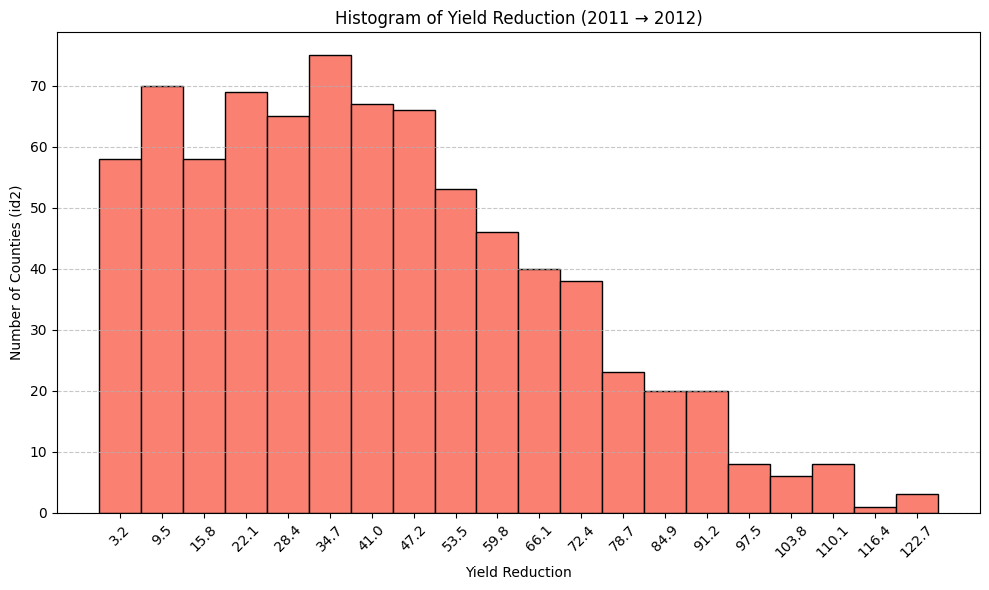

In [17]:
# Subset and pivot
df = gridMET_augmented[['id2', 'year', 'yield']]
pivot_df = df.pivot(index='id2', columns='year', values='yield')

# Drop rows missing 2011 or 2012
pivot_df = pivot_df.dropna(subset=[2011, 2012])

# Calculate yield reduction
pivot_df['yield_reduction'] = pivot_df[2011] - pivot_df[2012]

# Keep only reduced-yield counties
reduced_yield_df = pivot_df[pivot_df['yield_reduction'] > 80]

# Plot histogram and capture bin edges
plt.figure(figsize=(10, 6))
counts, bins, _ = plt.hist(reduced_yield_df['yield_reduction'], bins=20, color='salmon', edgecolor='black')

# Set x-ticks at bin centers or edges
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.xticks(bin_centers, rotation=45)

plt.title("Histogram of Yield Reduction (2011 → 2012)")
plt.xlabel("Yield Reduction")
plt.ylabel("Number of Counties (id2)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

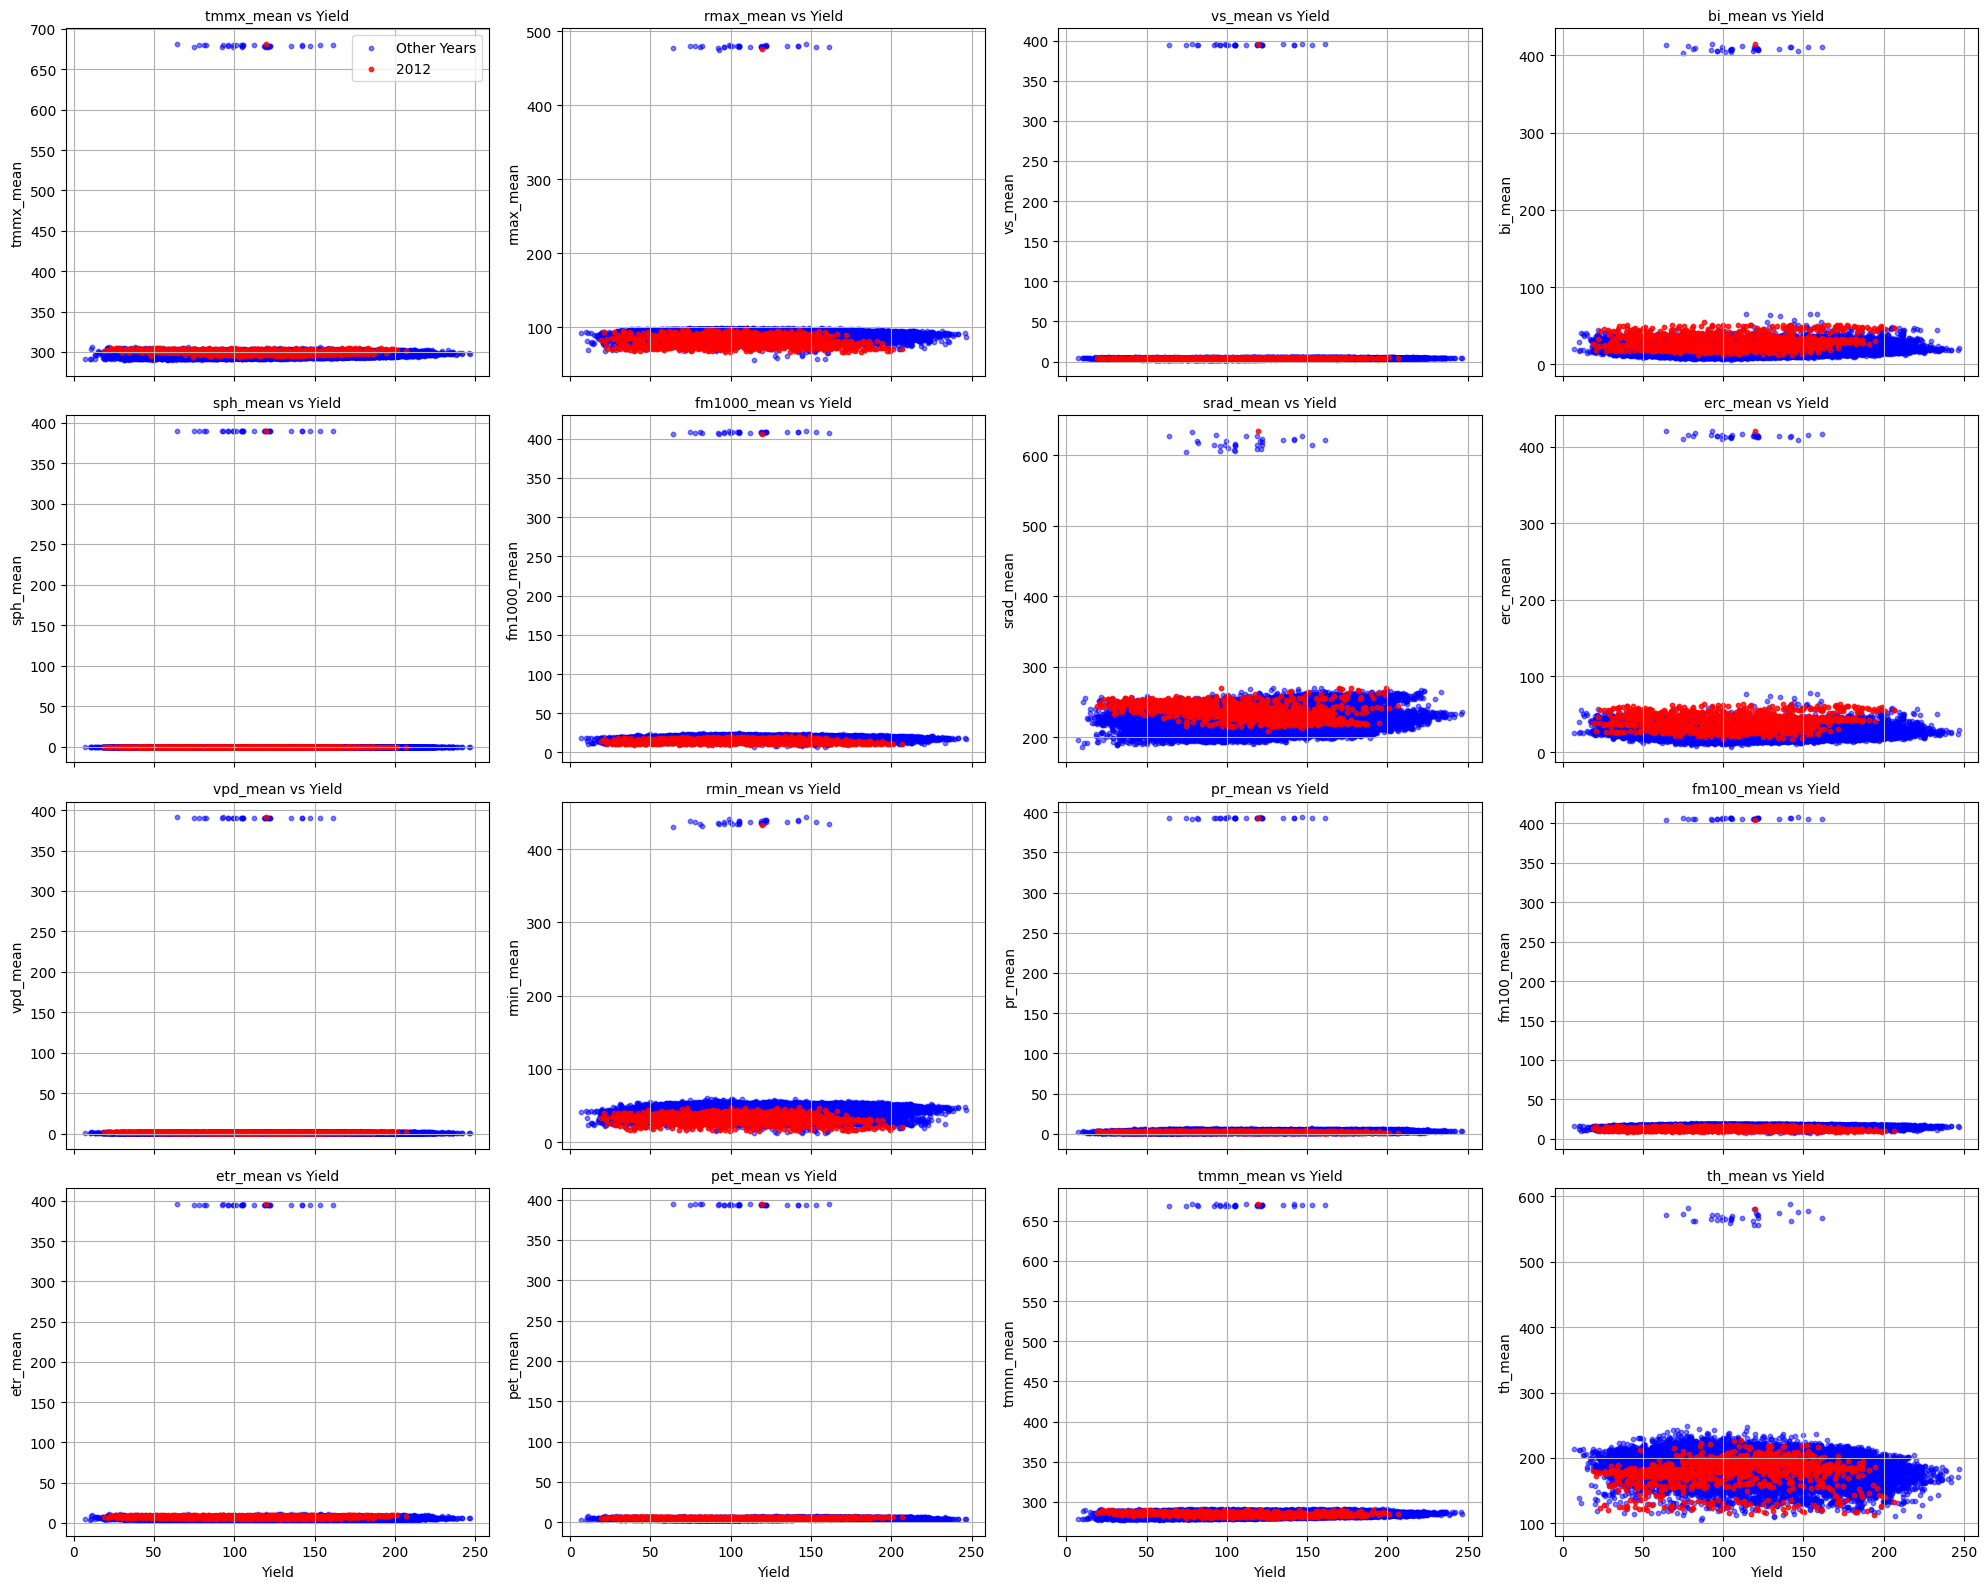

In [184]:
import matplotlib.pyplot as plt

# Features to plot (excluding yield stats and metadata columns)
features_to_plot = [
    'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean', 'sph_mean',
    'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean', 'rmin_mean',
    'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean', 'tmmn_mean', 'th_mean'
]

# Create a mask for 2012
is_2012 = gridMET_augmented['year'] == 2012

# Set up grid dimensions
n_cols = 4
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4), sharex=True)
axes = axes.flatten()

# Plot each feature vs yield
for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    
    # Other years (blue)
    ax.scatter(gridMET_augmented.loc[~is_2012, 'yield'],
               gridMET_augmented.loc[~is_2012, feature],
               color='blue', alpha=0.5, label='Other Years', s=10)
    
    # Year 2012 (red)
    ax.scatter(gridMET_augmented.loc[is_2012, 'yield'],
               gridMET_augmented.loc[is_2012, feature],
               color='red', alpha=0.8, label='2012', s=10)
    
    ax.set_title(f'{feature} vs Yield', fontsize=10)
    ax.set_ylabel(feature)
    if i >= (n_rows - 1) * n_cols:
        ax.set_xlabel('Yield')
    ax.grid(True)

# Remove empty subplots
for j in range(len(features_to_plot), len(axes)):
    fig.delaxes(axes[j])

# Add legend to the first subplot
axes[0].legend()

plt.tight_layout()
plt.show()

# Extremal Random Forest

### 📉 Extreme Low-Yield Prediction via Random Forest & Generalized Pareto Distribution

This section implements a method to estimate **extreme low yield values** (e.g., 4th percentile) using a combination of:
- **Random Forests** to define local neighborhoods based on tree structure, and
- **Generalized Pareto Distribution (GPD)** fitting for tail extrapolation.

---

#### 🔹 1. Data Splitting
- The dataset `gridMET_augmented` is divided by year:
  - **Training data**: All years before 2012
  - **Test data**: Only the year 2012

This setup simulates a historical forecasting scenario, where we attempt to predict yields for 2012 using all available past data.

---

#### 🔹 2. Random Forest for Local Structure
- A `RandomForestRegressor` is trained to learn general yield behavior.
- After training, `.apply()` is used to record **leaf indices** for all samples.
- Leaf indices indicate which samples fall into the same terminal nodes, helping us measure proximity between data points.

---

#### 🔹 3. Neighborhood Similarity
- For each test point, the function `get_rf_neighbors`:
  - Finds training samples that land in the same leaf across the forest.
  - Computes a similarity weight for each training sample based on the number of shared leaves.

These weights define a **local neighborhood** around each test point in a data-adaptive way.

---

#### 🔹 4. Extreme Value Modeling
- For each test sample:
  - The top-10 most similar training samples (neighbors) are selected.
  - The **5th percentile** yield (`tau_n = 0.05`) is computed.
  - Training yields below this threshold are identified as **lower-tail exceedances**.
- The exceedances are **flipped** (i.e., `threshold - yield`) to fit a **Generalized Pareto Distribution (GPD)** using `scipy.stats.genpareto`.
- If the GPD fit is successful, we compute the **4th percentile** (`tau_extreme = 0.04`) using the GPD’s inverse CDF.

This allows us to extrapolate beyond observed data to estimate more extreme low-yield events.

---

#### 🔹 5. Fallback Handling
- If there are too few similar training samples or too few exceedances (e.g., < 5), we fall back to the 5th percentile threshold to avoid unreliable extrapolation.

---

#### ✅ Outcome
This method provides **robust, locally-adaptive, and statistically grounded predictions** for extreme low yields by:
- Leveraging structural similarity in Random Forests, and
- Applying Extreme Value Theory via GPD to model the lower tail of the distribution.

This approach is especially useful in agricultural yield forecasting where extreme low outcomes (e.g., drought years) have significant importance.


In [172]:
train_df = gridMET_augmented[gridMET_augmented['year'] < 2012].copy().reset_index(drop=True)
test_df = gridMET_augmented[gridMET_augmented['year'] == 2012].copy().reset_index(drop=True)

# Features and target
feature_cols = [col for col in gridMET_augmented.columns if col not in ['yield']]
# features_cols = ['yield_mean', 'year', 'yield_max', 'tmmx_mean', 'erc_mean']

X_train = train_df[feature_cols].reset_index(drop=True)
y_train = train_df['yield'].reset_index(drop=True)

X_test = test_df[feature_cols].reset_index(drop=True)
y_test = test_df['yield'].reset_index(drop=True)

In [173]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [174]:
# Get leaf indices for each sample
train_leaves = rf.apply(X_train)
test_leaves = rf.apply(X_test)

def get_rf_neighbors(test_leaf, train_leaves):
    # For each tree, find training samples in same leaf
    matches = [np.where(train_leaves[:, i] == test_leaf[i])[0] for i in range(test_leaf.shape[0])]
    # Flatten and count occurrences
    neighbor_counts = np.bincount(np.concatenate(matches), minlength=len(train_leaves))
    return neighbor_counts / rf.n_estimators  # normalize to get weight

In [175]:
from scipy.stats import genpareto

def fit_gpd(exceedances, threshold):
    excess = exceedances - threshold
    if len(excess) < 5:
        return None  # too few samples
    c, loc, scale = genpareto.fit(excess, floc=0)  # force threshold to be zero
    return c, scale

In [176]:
tau_n = 0.05        
tau_extreme = 0.04  
predictions = []

# Add id2 and yield to training features for reference
X_train_df = X_train.copy()
X_train_df['yield'] = y_train

for i in range(len(X_test)):
    test_point = X_test.iloc[i]
    test_id2 = test_df.iloc[i]['id2']
    test_leaf = test_leaves[i, :]
    
    # Filter training samples from the same county
    # local_train_idx = train_df[train_df['id2'] == test_id2].index
    local_train_idx = train_df.index
    
    if len(local_train_idx) < 20:
        predictions.append(np.nan)
        continue

    # Extract relevant training data for that county
    local_train_leaves = train_leaves[local_train_idx]
    y_local = y_train.iloc[local_train_idx].reset_index(drop=True)
    X_local = X_train.iloc[local_train_idx].reset_index(drop=True)

    # Get similarity weights via RF structure
    weights = get_rf_neighbors(test_leaf, local_train_leaves)
    if weights.sum() == 0:
        predictions.append(np.nan)
        continue

    # Choose top-k most similar neighbors
    top_k_idx = np.argsort(weights)[-10:]  
    y_neighbors = y_local.iloc[top_k_idx]

    # Compute intermediate low-yield threshold
    threshold = np.quantile(y_neighbors, tau_n)

    # Select only yields below threshold (the "exceedances" in lower tail)
    low_mask = y_neighbors < threshold
    y_exceed = y_neighbors[low_mask]

    if len(y_exceed) < 5:
        predictions.append(threshold)  # fallback to threshold
        continue

    # Reverse the exceedance to apply upper-tail GPD logic
    reverse_exceedance = threshold - y_exceed.values  # flip for GPD

    # Fit GPD on reversed excess with threshold = 0
    gpd_result = fit_gpd(reverse_exceedance, threshold=0)
    if gpd_result is None:
        predictions.append(threshold)
        continue

    c, scale = gpd_result

    # Extrapolate low quantile using inverse GPD
    p_tail = (tau_n - tau_extreme) / tau_n
    if c != 0:
        q_extreme = threshold - (scale / c) * (p_tail ** (-c) - 1)
    else:
        q_extreme = threshold + scale * np.log(1 / p_tail)

    predictions.append(q_extreme)

In [177]:
len(predictions), len(y_test)

(1087, 1087)

In [178]:
# Convert predictions to float and filter NaNs
y_preds = [float(p) for p in predictions]

# Create mask for non-NaN predictions
mask = ~np.isnan(y_preds)

# Apply mask to both predictions and true values
y_preds_filtered = np.array(y_preds)[mask]
y_test_filtered = np.array(y_test)[mask]

# Calculate metrics
r2 = r2_score(y_test_filtered, y_preds_filtered)
rmse = np.sqrt(mean_squared_error(y_test_filtered, y_preds_filtered))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: 0.118
RMSE: 38.440


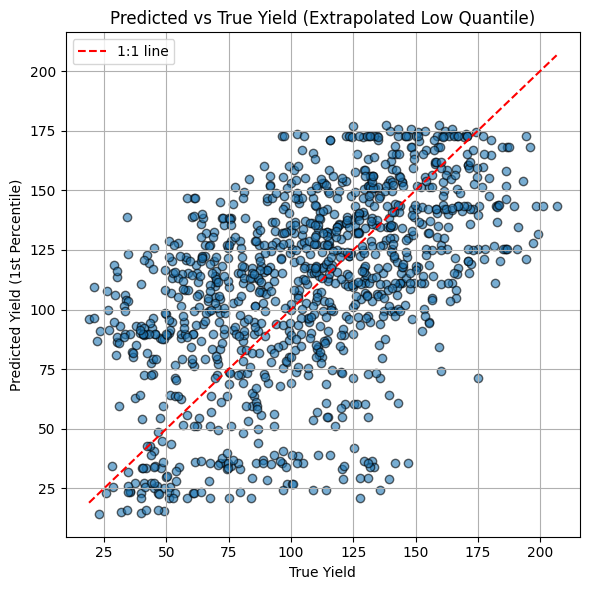

In [156]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_filtered, y_preds_filtered, alpha=0.6, edgecolor='k')
plt.plot([y_test_filtered.min(), y_test_filtered.max()],
         [y_test_filtered.min(), y_test_filtered.max()],
         'r--', label='1:1 line')

plt.xlabel('True Yield')
plt.ylabel('Predicted Yield (1st Percentile)')
plt.title('Predicted vs True Yield (Extrapolated Low Quantile)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Percentile Prediction

In [133]:
train_df = gridMET_augmented[gridMET_augmented['year'] < 2012].copy().reset_index(drop=True)
test_df = gridMET_augmented[gridMET_augmented['year'] == 2012].copy().reset_index(drop=True)

# Training data stats
tmmx_train = train_df['tmmx_mean'].values
erc_train = train_df['erc_mean'].values
yield_train = train_df['yield'].values

# For each test sample
predicted_yields = []

for i in range(len(test_df)):
    tmmx_val = test_df.iloc[i]['tmmx_mean']
    erc_val = test_df.iloc[i]['erc_mean']

    # Get percentiles of each feature
    tmmx_percentile = np.mean(tmmx_val >= tmmx_train)  # Empirical CDF
    erc_percentile = np.mean(erc_val >= erc_train)

    # Step 3: Average percentile (for tail exposure)
    avg_percentile = (tmmx_percentile + erc_percentile) / 2
    new_avg_percentile = 1.0 - avg_percentile

    # Step 4: Invert this to get the same percentile yield (lower tail focus)
    # Since we care about LOW yields, we use that as the quantile
    predicted_yield = np.quantile(yield_train, new_avg_percentile)

    predicted_yields.append(predicted_yield)

In [134]:
avg_percentile

np.float64(0.7743039375582479)

In [135]:
# Remove NaNs if any
y_true = test_df['yield'].values
mask = ~np.isnan(predicted_yields)
y_pred = np.array(predicted_yields)[mask]
y_true = y_true[mask]

r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

R²: -0.993
RMSE: 57.798


In [123]:
y_preds = [float(p) for p in predictions]

# GEV 
### Extreme Value Analysis Using Generalized Extreme Value (GEV) Distribution

This section fits a Generalized Extreme Value (GEV) distribution to historical crop yield data (before 2012) to model the distribution of yields. We then use this fitted distribution to assess whether 2012 yields are extreme compared to the historical variability.

**Steps explained:**

1. **Fit GEV to historical yields:**
   - Extract yields from years before 2012.
   - Estimate the shape (`c`), location (`loc`), and scale (`scale`) parameters of the GEV distribution using `genextreme.fit`.
   - The fitting is performed on the actual yield values to model the upper tail (high yields).

2. **Prepare 2012 test data:**
   - Create a test DataFrame containing only 2012 data and reset its index.
   - Extract the 2012 yield values.

3. **Calculate exceedance probabilities:**
   - Compute the cumulative distribution function (CDF) values for the 2012 yields under the fitted GEV model.
   - The CDF value represents the probability of observing a yield less than or equal to a given yield under the historical distribution.
   - Low CDF values (e.g., below 0.05) indicate yields that are unusually low compared to historical data (potential extreme low yields).

4. **Flag extreme values:**
   - Assign a flag `"Y"` to yields with CDF probabilities below 0.05, indicating extreme low yields.
   - Assign `"N"` otherwise.

This methodology leverages extreme value theory to identify unusually low crop yields in 2012 relative to the historical distribution of yields.


In [176]:
from scipy.stats import genextreme
import matplotlib.pyplot as plt

# Fit GEV on pre-2012 yields
y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c, loc, scale = genextreme.fit(-y_train)  # Fit on negative to model lower tail

# Get 2012 yields
test_df_2012 = gridMET_augmented[gridMET_augmented['year'] == 2012].copy()
y_test = test_df_2012['yield']

# Compute probabilities
gev_prob = genextreme.cdf(-y_test, c, loc=loc, scale=scale)  # Again use negative for lower tail
test_df_2012['gev_prob'] = gev_prob
test_df_2012['extreme_flag'] = test_df_2012['gev_prob'].apply(lambda p: 'Y' if p < 0.05 else 'N')
test_df_2012 = test_df_2012.reset_index()

In [177]:
print(test_df_2012[["id2", "year", "yield", "gev_prob", "extreme_flag"]])
print("===============================")
print(test_df_2012['extreme_flag'].value_counts())
print("===============================")
print("GEV shape parameter (tail):", c)     

       id2  year  yield  gev_prob extreme_flag
0      119  2012  182.7  0.014500            Y
1      124  2012  191.1  0.005752            Y
2      136  2012  144.6  0.211628            N
3      140  2012  160.3  0.090418            N
4      142  2012  166.9  0.057385            N
...    ...   ...    ...       ...          ...
1082  3121  2012   96.7  0.734003            N
1083  3122  2012  128.5  0.385873            N
1084  3123  2012  118.1  0.508430            N
1085  3124  2012  109.8  0.602780            N
1086  3125  2012  109.6  0.604969            N

[1087 rows x 5 columns]
extreme_flag
N    1018
Y      69
Name: count, dtype: int64
GEV shape parameter (tail): 0.1904489255590619


In [178]:
###################### Tagging the Extreme Event (Just Intersection) ######################

from scipy.stats import genextreme

# List of meteorological feature columns
met_cols = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean',
            'sph_mean', 'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean',
            'rmin_mean', 'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean',
            'tmmn_mean', 'th_mean']

# Copy 2012 test data for all extremes calculations
test_df_2012_met_extremes = gridMET_augmented[gridMET_augmented['year'] == 2012].copy().reset_index(drop=True)

# Prepare a dictionary to store matches results
matches_results = {}

for feature in met_cols:
    
    # Fit GEV on pre-2012 data for this feature
    # print(feature)
    train_data = gridMET_augmented[gridMET_augmented['year'] < 2012][feature].dropna()
    c, loc, scale = genextreme.fit(train_data)
    
    test_feature_data = test_df_2012_met_extremes[feature]
    
    gev_survival_prob = 1 - genextreme.cdf(test_feature_data, c, loc=loc, scale=scale)
    
    # Add GEV survival prob and extreme flag columns
    prob_col = f'gev_prob_{feature}_high'
    flag_col = f'extreme_flag_{feature}_high'
    test_df_2012_met_extremes[prob_col] = gev_survival_prob
    test_df_2012_met_extremes[flag_col] = pd.Series(gev_survival_prob).apply(lambda p: 'Y' if p < 0.05 else 'N')
    
    # Merge with yield extreme flags for comparison
    merged = test_df_2012[['id2', 'extreme_flag']].merge(
        test_df_2012_met_extremes[['id2', flag_col]],
        on='id2', how='inner'
    )
    
    # Count matches where both are 'Y'
    both_extreme = merged[(merged['extreme_flag'] == 'Y') & (merged[flag_col] == 'Y')]
    matches_results[feature] = both_extreme.shape[0]
    
# Print summary of matches
for feature, count in matches_results.items():
    print(f"{feature}: {count} matches with yield-based extreme flags")

tmmx_mean: 10 matches with yield-based extreme flags
rmax_mean: 0 matches with yield-based extreme flags
vs_mean: 0 matches with yield-based extreme flags
bi_mean: 48 matches with yield-based extreme flags
sph_mean: 0 matches with yield-based extreme flags
fm1000_mean: 0 matches with yield-based extreme flags
srad_mean: 20 matches with yield-based extreme flags
erc_mean: 68 matches with yield-based extreme flags
vpd_mean: 48 matches with yield-based extreme flags
rmin_mean: 0 matches with yield-based extreme flags
pr_mean: 0 matches with yield-based extreme flags
fm100_mean: 0 matches with yield-based extreme flags
etr_mean: 48 matches with yield-based extreme flags
pet_mean: 36 matches with yield-based extreme flags
tmmn_mean: 0 matches with yield-based extreme flags
th_mean: 0 matches with yield-based extreme flags


In [179]:
###################### Tagging the Extreme Event (Compare with Total) ######################

from scipy.stats import genextreme

# Fit GEV on pre-2012 yields
y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c_yield, loc_yield, scale_yield = genextreme.fit(-y_train)

# Get 2012 data and compute yield-based extremes
test_df_2012 = gridMET_augmented[gridMET_augmented['year'] == 2012].copy().reset_index(drop=True)
y_test = test_df_2012['yield']

# Compute yield-based extreme flags
gev_prob_yield = genextreme.cdf(-y_test, c_yield, loc=loc_yield, scale=scale_yield)
test_df_2012['gev_prob_yield'] = gev_prob_yield
test_df_2012['extreme_flag'] = test_df_2012['gev_prob_yield'].apply(lambda p: 'Y' if p < 0.05 else 'N')

# Meteorological feature list
met_cols = ['tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean',
            'sph_mean', 'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean',
            'rmin_mean', 'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean',
            'tmmn_mean', 'th_mean']

# Store result counts
summary_rows = []

for feature in met_cols:
    # Fit GEV on pre-2012 feature data
    train_feature_data = gridMET_augmented[gridMET_augmented['year'] < 2012][feature].dropna()
    c, loc, scale = genextreme.fit(train_feature_data)

    # Compute survival prob (upper tail) for 2012 test data
    test_feature_data = test_df_2012[feature]
    gev_surv_prob = 1 - genextreme.cdf(test_feature_data, c, loc=loc, scale=scale)

    # Flag extreme feature values
    prob_col = f'gev_prob_{feature}_high'
    flag_col = f'extreme_flag_{feature}_high'
    test_df_2012[prob_col] = gev_surv_prob
    test_df_2012[flag_col] = np.where(gev_surv_prob < 0.05, 'Y', 'N')

    # Count how many are flagged as extreme for this feature
    total_feature_extremes = (test_df_2012[flag_col] == 'Y').sum()

    # Count overlap with yield-based extremes
    match_both_extreme = ((test_df_2012['extreme_flag'] == 'Y') & (test_df_2012[flag_col] == 'Y')).sum()

    summary_rows.append({
        'Feature': feature,
        'Feature Extremes (Y)': total_feature_extremes,
        'Matches with Yield Extremes (Y & Y)': match_both_extreme
    })

# Create summary DataFrame
summary_df = pd.DataFrame(summary_rows)

# Print results
print(summary_df.sort_values(by='Matches with Yield Extremes (Y & Y)', ascending=False).to_string(index=False))

    Feature  Feature Extremes (Y)  Matches with Yield Extremes (Y & Y)
   erc_mean                   617                                   68
    bi_mean                   466                                   48
   vpd_mean                   603                                   48
   etr_mean                   504                                   48
   pet_mean                   424                                   36
  srad_mean                   142                                   20
  tmmx_mean                    40                                   10
  rmax_mean                     1                                    0
    vs_mean                     1                                    0
   sph_mean                     1                                    0
fm1000_mean                     1                                    0
  rmin_mean                     1                                    0
    pr_mean                     1                                    0
 fm100

In [112]:
import pandas as pd

# Select the relevant features
features = ['pr_mean', 'tmmx_mean', 'tmmn_mean']

# Split into extreme and non-extreme groups
extreme_df = test_df_2012[test_df_2012['extreme_flag'] == 'Y']
non_extreme_df = test_df_2012[test_df_2012['extreme_flag'] == 'N']

# Summary comparison function
def compare_feature_stats(extreme_df, non_extreme_df, features):
    rows = []
    for feat in features:
        row = {
            'Feature': feat,
            'Extreme Mean': extreme_df[feat].mean(),
            'Non-Extreme Mean': non_extreme_df[feat].mean(),
            'Extreme Std': extreme_df[feat].std(),
            'Non-Extreme Std': non_extreme_df[feat].std(),
            'Mean Diff (Extreme - Non)': extreme_df[feat].mean() - non_extreme_df[feat].mean()
        }
        rows.append(row)
    return pd.DataFrame(rows)

# Run comparison
comparison_df = compare_feature_stats(extreme_df, non_extreme_df, features)

# Show results
print(comparison_df.to_string(index=False))

  Feature  Extreme Mean  Non-Extreme Mean  Extreme Std  Non-Extreme Std  Mean Diff (Extreme - Non)
  pr_mean      2.061169          2.788974     0.651909        12.562720                  -0.727805
tmmx_mean    300.410403        300.756675     2.348109        12.464751                  -0.346272
tmmn_mean    284.680795        285.485015     1.832749        12.556636                  -0.804219


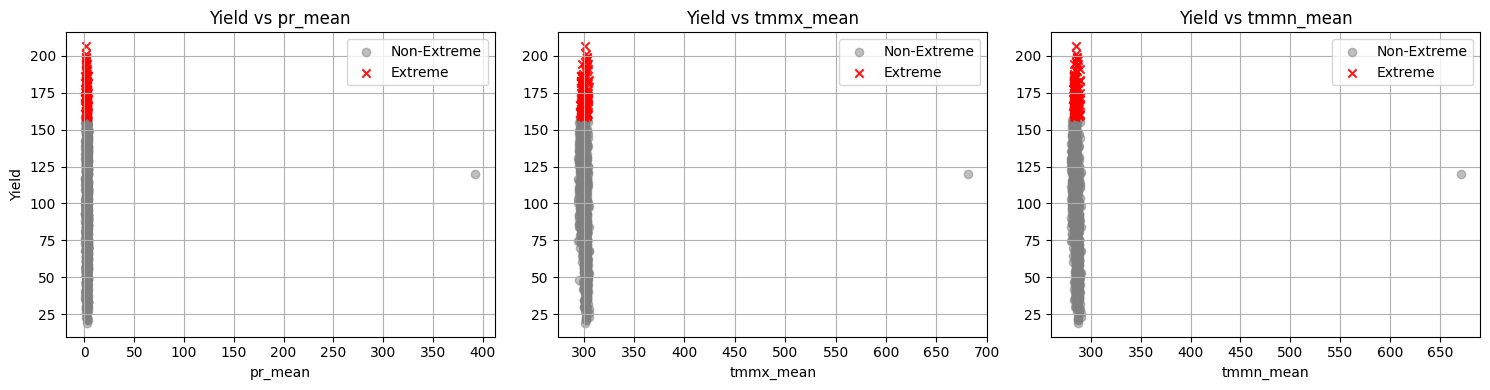

In [113]:
import matplotlib.pyplot as plt

# List of features to plot
features = ['pr_mean', 'tmmx_mean', 'tmmn_mean']

# Set up plots
plt.figure(figsize=(15, 4))

for i, feature in enumerate(features):
    plt.subplot(1, 3, i+1)

    # Plot non-extreme points
    non_extreme = test_df_2012[test_df_2012['extreme_flag'] == 'N']
    plt.scatter(non_extreme[feature], non_extreme['yield'], 
                color='gray', alpha=0.5, label='Non-Extreme', marker='o')

    # Plot extreme points
    extreme = test_df_2012[test_df_2012['extreme_flag'] == 'Y']
    plt.scatter(extreme[feature], extreme['yield'], 
                color='red', alpha=0.9, label='Extreme', marker='x')

    plt.xlabel(feature)
    if i == 0:
        plt.ylabel('Yield')
    plt.title(f'Yield vs {feature}')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

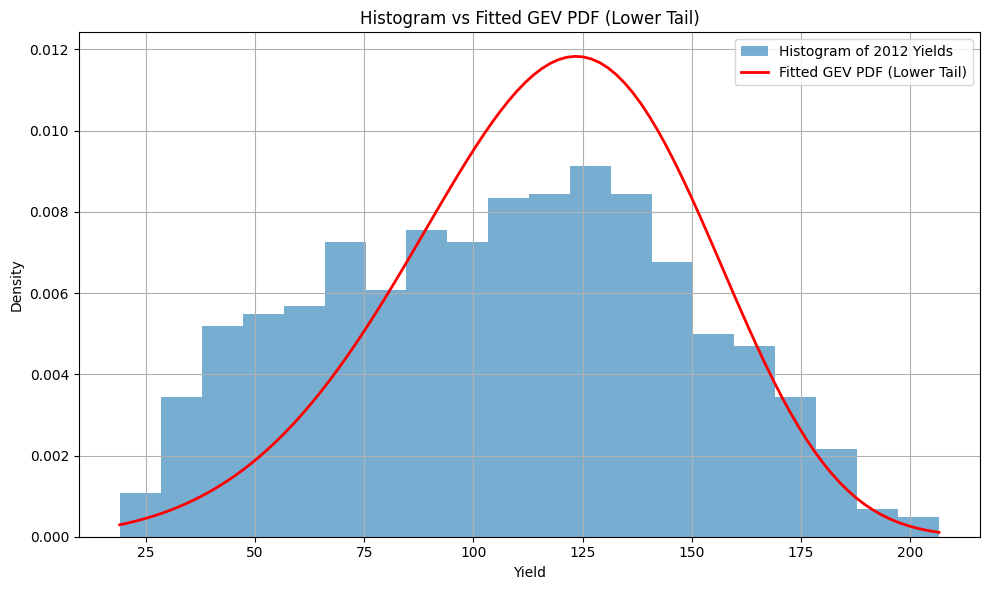

In [43]:
###################### Histogram vs Density Plot ######################

y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c, loc, scale = genextreme.fit(-y_train)  
y_test = gridMET_augmented[gridMET_augmented['year'] == 2012]['yield'].dropna()

x = np.linspace(y_test.min(), y_test.max(), 100)
x_neg = -x  

plt.figure(figsize=(10, 6))
plt.hist(y_test, bins = 20, density = True, alpha = 0.6, label = 'Histogram of 2012 Yields')

gev_pdf = genextreme.pdf(-x, c, loc=loc, scale=scale)
plt.plot(x, gev_pdf, 'r-', lw=2, label='Fitted GEV PDF (Lower Tail)')

plt.xlabel('Yield')
plt.ylabel('Density')
plt.title('Histogram vs Fitted GEV PDF (Lower Tail)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show

In [223]:
gridMET_augmented.columns

Index(['id2', 'year', 'tmmx_mean', 'rmax_mean', 'vs_mean', 'bi_mean',
       'sph_mean', 'fm1000_mean', 'srad_mean', 'erc_mean', 'vpd_mean',
       'rmin_mean', 'pr_mean', 'fm100_mean', 'etr_mean', 'pet_mean',
       'tmmn_mean', 'th_mean', 'yield_prev_year', 'yield_5yr_mean',
       'yield_min', 'yield_max', 'yield_std', 'yield_mean', 'yield_trend_pred',
       'yield'],
      dtype='object')

In [191]:
from scipy.stats import genextreme

# Get 2012 test data (copy to new variable)
test_df_2012_tmmx_extremes = gridMET_augmented[gridMET_augmented['year'] == 2012].copy().reset_index(drop=True)

# Fit GEV on 'tmmx_mean' from pre-2012 data to find extremes in temperature
tmmx_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['tmmx_mean'].dropna()

# Fit GEV to model upper tail (extreme high temps)
c_tmmx, loc_tmmx, scale_tmmx = genextreme.fit(tmmx_train)

# Calculate GEV survival function (1 - CDF) for test data tmmx_mean to get probability of high temp extremes
tmmx_test = test_df_2012_tmmx_extremes['tmmx_mean']

# Higher values => low survival function (probability of being extreme high)
gev_survival_prob = 1 - genextreme.cdf(tmmx_test, c_tmmx, loc=loc_tmmx, scale=scale_tmmx)
test_df_2012_tmmx_extremes['gev_prob_tmmx_high'] = gev_survival_prob

# Flag 'Y' for high temperature extremes (e.g. top 5% highest temps)
test_df_2012_tmmx_extremes['extreme_flag_tmmx_high'] = test_df_2012_tmmx_extremes['gev_prob_tmmx_high'].apply(lambda p: 'Y' if p < 0.05 else 'N')

# New DataFrame
print(test_df_2012_tmmx_extremes[['tmmx_mean', 'yield', 'gev_prob_tmmx_high', 'extreme_flag_tmmx_high']].head())

    tmmx_mean  yield  gev_prob_tmmx_high extreme_flag_tmmx_high
0  304.076157  182.7            0.048456                      Y
1  304.342885  191.1            0.044098                      Y
2  304.151468  144.6            0.047183                      Y
3  304.274436  160.3            0.045177                      Y
4  304.437700  166.9            0.042648                      Y


In [192]:
test_df_2012_tmmx_extremes['extreme_flag_tmmx_high'].value_counts()

extreme_flag_tmmx_high
N    1047
Y      40
Name: count, dtype: int64

In [193]:
# Merge on 'id2' to compare flags side-by-side
merged = test_df_2012[['id2', 'extreme_flag']].merge(
    test_df_2012_tmmx_extremes[['id2', 'extreme_flag_tmmx_high']],
    on='id2', how='inner'
)

# Find rows where both flags are 'Y'
both_extreme = merged[(merged['extreme_flag'] == 'Y') & (merged['extreme_flag_tmmx_high'] == 'Y')]

# Number of matching 'Y' flags
num_matches = both_extreme.shape[0]

print(f"Number of id2s flagged as 'Y' in both datasets: {num_matches}")

Number of id2s flagged as 'Y' in both datasets: 10


# Weighted Regression (Whole test)

In [139]:
### Identify Extremes in Pre-2012 Data

y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c, loc, scale = genextreme.fit(-y_train)

train_df = gridMET_augmented[gridMET_augmented['year'] < 2012].copy()
train_df['gev_prob'] = genextreme.cdf(-train_df['yield'], c, loc=loc, scale=scale)

threshold = train_df['gev_prob'].quantile(0.05)
train_df['extreme_flag'] = (train_df['gev_prob'] <= threshold).astype(int)

In [140]:
### Select N Extreme 2012 Samples

test_df_2012 = gridMET_augmented[gridMET_augmented["year"] == 2012].copy()
sorted_2012 = test_df_2012.sort_values(by="yield", ascending=True)
few_shot_2012 = sorted_2012.head(5)
few_shot_2012 = few_shot_2012.reset_index()

In [166]:
### Assign Weights

hist_extreme = train_df[train_df["extreme_flag"] == 1].copy()
hist_regular = train_df[train_df["extreme_flag"] == 0].copy()

hist_regular["sample_weight"] = 1.0
hist_extreme["sample_weight"] = 5.0
few_shot_2012["sample_weight"] = 200.0

train_combined = pd.concat([hist_regular, hist_extreme, few_shot_2012], ignore_index=True)

print("Training Set Sizes:")
print("  Regular historical:", len(hist_regular))
print("  Historical extreme:", len(hist_extreme))
print("  2012 few-shot:", len(few_shot_2012))

print("\nSample Weights Summary:")
print(train_combined["sample_weight"].value_counts())

Training Set Sizes:
  Regular historical: 32616
  Historical extreme: 1720
  2012 few-shot: 5

Sample Weights Summary:
sample_weight
1.0      32616
5.0       1720
200.0        5
Name: count, dtype: int64


In [167]:
##################### Performing weighted-lasso ##########################################

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

def run_weighted_lasso(train_df, test_df, target_col='yield', weight_col='sample_weight', alpha=1.0):
    # Drop non-feature columns
    exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index'] ##'year'
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    # Extract feature matrices and targets
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    weights = train_df[weight_col]
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    # Create pipeline with scaling + Lasso
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha) ###fit_intercept=True, max_iter=10000
    )
    
    # Fit model using sample weights
    model.fit(X_train, y_train, lasso__sample_weight=weights)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    return model, y_test, y_pred

few_shot_ids = few_shot_2012["id2"].unique()
test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()

model, y_true, y_pred = run_weighted_lasso(train_combined, test_df_2012_clean, alpha=0.1)
print("Test RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("Test R²:", r2_score(y_true, y_pred))

Test RMSE: 28.286961914549572
Test R²: 0.5151543627526127


In [168]:
##################### Performing un-weighted-lasso ##########################################

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def run_unweighted_lasso(train_df, test_df, target_col='yield', alpha=1.0):
    exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'year', 'index']
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha) ##, fit_intercept=True, max_iter=10000
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    return model, y_test, y_pred

# Exclude few-shot examples from test set
few_shot_ids = few_shot_2012["id2"].unique()
test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()
model, y_true, y_pred = run_unweighted_lasso(train_combined, test_df_2012_clean, alpha=0.005)

print("Test RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("Test R²:", r2_score(y_true, y_pred))

Test RMSE: 30.84198889682765
Test R²: 0.4236110668949645


/Users/guptsh/shrey_tf_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.632e+06, tolerance: 4.095e+03
  model = cd_fast.enet_coordinate_descent(


# TrAdaBoost.R2

In [103]:
from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# Split source (historical) and target (few-shot 2012)
exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index']  # Non-features
feature_cols = [col for col in train_df.columns if col not in exclude_cols]

# Source: historical
X_source = train_df[feature_cols].copy()
y_source = train_df['yield'].copy()

# source_year_cutoff = 2012 - 10  # 2002
# train_source_last_10yrs = train_df[train_df['year'] >= source_year_cutoff]
# X_source = train_source_last_10yrs[feature_cols].copy()
# y_source = train_source_last_10yrs['yield'].copy()


# Target: few-shot 2012 extreme
X_target = few_shot_2012[feature_cols].copy()
y_target = few_shot_2012['yield'].copy()

# Test: remaining 2012
few_shot_ids = few_shot_2012["id2"].unique()
test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()
X_test = test_df_2012_clean[feature_cols]
y_test = test_df_2012_clean['yield']

# Standardize (recommended)
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=None,
    n_estimators=5,
    lr = 1.2,
    Xt=X_target_scaled,
    yt=y_target
)

# model = TwoStageTrAdaBoostR2(
#     estimator=None,
#     n_estimators=50,
#     Xt=X_target_scaled,
#     yt=y_target
# )

model.fit(X_source_scaled, y_source)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

Iteration 0 - Error: 0.5380
Iteration 1 - Error: 0.6111
Iteration 2 - Error: 0.6355
Iteration 3 - Error: 0.6147
Iteration 4 - Error: 0.5339
Test RMSE: 29.9611820785556
Test R²: 0.4560627911749514


In [105]:
################## TrAdaBoost on Top 20% ##################

from adapt.instance_based import TrAdaBoostR2, TwoStageTrAdaBoostR2
from sklearn.tree import DecisionTreeRegressor
# from sklearn.metrics import mean_squared_error, r2_score
# from sklearn.preprocessing import StandardScaler
# import numpy as np

# Split source (historical) and target (few-shot 2012)
exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index']  # Non-features
feature_cols = [col for col in train_df.columns if col not in exclude_cols]

# Source: historical
X_source = train_df[feature_cols].copy()
y_source = train_df['yield'].copy()

# source_year_cutoff = 2012 - 5  # 2002
# train_source_last_10yrs = train_df[train_df['year'] >= source_year_cutoff]
# X_source = train_source_last_10yrs[feature_cols].copy()
# y_source = train_source_last_10yrs['yield'].copy()

# Target: few-shot 2012 extreme
X_target = few_shot_2012[feature_cols].copy()
y_target = few_shot_2012['yield'].copy()

# Test: remaining 2012
# few_shot_ids = few_shot_2012["id2"].unique()
# test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()
# X_test = test_df_2012_clean[feature_cols]
# y_test = test_df_2012_clean['yield']


# Select bottom 20% (most extreme) 2012 yields for evaluation
extreme_cutoff = test_df_2012_clean["yield"].quantile(0.20)
extreme_2012_test = test_df_2012_clean[test_df_2012_clean["yield"] <= extreme_cutoff].copy()
X_test = extreme_2012_test[feature_cols]
y_test = extreme_2012_test['yield']


# Standardize (recommended)
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=None,
    n_estimators=5,
    lr = 1.2,
    Xt=X_target_scaled,
    yt=y_target
)

# model = TwoStageTrAdaBoostR2(
#     estimator=None,
#     n_estimators=50,
#     Xt=X_target_scaled,
#     yt=y_target
# )

model.fit(X_source_scaled, y_source)

# Predict and evaluate
y_pred = model.predict(X_test_scaled)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R²:", r2_score(y_test, y_pred))

Iteration 0 - Error: 0.5380
Iteration 1 - Error: 0.6111
Iteration 2 - Error: 0.6355
Iteration 3 - Error: 0.6147
Iteration 4 - Error: 0.5339
Test RMSE: 36.684613170332156
Test R²: -9.626793637031662


In [121]:
from scipy.stats import genextreme
from sklearn.tree import DecisionTreeRegressor
from adapt.instance_based import TrAdaBoostR2

### --- STEP 1: Tag yield-based extremes using GEV --- ###
y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c, loc, scale = genextreme.fit(-y_train)

train_df = gridMET_augmented[gridMET_augmented['year'] < 2012].copy()
train_df['gev_prob'] = genextreme.cdf(-train_df['yield'], c, loc=loc, scale=scale)
threshold = train_df['gev_prob'].quantile(0.05)
train_df['extreme_flag'] = (train_df['gev_prob'] <= threshold).astype(int)

### --- STEP 2: Select few-shot samples --- ###

# Few-shot from 2012: 5 lowest yield counties
test_df_2012 = gridMET_augmented[gridMET_augmented["year"] == 2012].copy()
sorted_2012 = test_df_2012.sort_values(by="yield", ascending=True)
few_shot_2012 = sorted_2012.head(5).copy().reset_index(drop=True)

# Few-shot from 2007–2011: all extreme-tagged
# extreme_last5 = train_df[(train_df['year'] >= 2007) & (train_df['extreme_flag'] == 1)].copy()
# Filter last 5 years
train_last5 = train_df[train_df['year'] >= 2007].copy()

# Tag top 5% yields in addition to bottom 5%
# low_thresh = train_last5['yield'].quantile(0.05)
high_thresh = train_last5['yield'].quantile(0.95)

# Select low and high extremes
low_extremes = train_last5[train_last5['yield'] <= low_thresh]
high_extremes = train_last5[train_last5['yield'] >= high_thresh]

# Combine both tails
extreme_last5 = high_extremes.copy()
# extreme_last5 = pd.concat([low_extremes, high_extremes], ignore_index=True)

# Combine all few-shot samples
few_shot_combined = pd.concat([extreme_last5, few_shot_2012], ignore_index=True)
few_shot_combined["sample_weight"] = 40.0

### --- STEP 3: Source (historical non-extreme) --- ###
hist_regular = train_df[train_df["extreme_flag"] == 0].copy()
hist_regular["sample_weight"] = 1.0

### --- STEP 4: Prepare combined training data --- ###
train_combined = pd.concat([hist_regular, few_shot_combined], ignore_index=True)

print("Training Set Sizes:")
print("  Historical regular:", len(hist_regular))
print("  Few-shot (2007–2011 extremes + 2012 lows):", len(few_shot_combined))
print("\nSample Weight Counts:\n", train_combined["sample_weight"].value_counts())

### --- STEP 5: Prepare test data (bottom 20% of 2012 yields) --- ###
few_shot_ids = few_shot_combined["id2"].unique()
test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()

extreme_cutoff = test_df_2012_clean["yield"].quantile(0.20)
extreme_2012_test = test_df_2012_clean[test_df_2012_clean["yield"] <= extreme_cutoff].copy()

### --- STEP 6: Feature prep --- ###
exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index', 'year']
feature_cols = [col for col in train_combined.columns if col not in exclude_cols]

X_source = hist_regular[feature_cols].copy()
y_source = hist_regular['yield'].copy()

X_target = few_shot_combined[feature_cols].copy()
y_target = few_shot_combined['yield'].copy()

X_test = extreme_2012_test[feature_cols].copy()
y_test = extreme_2012_test['yield'].copy()

### --- STEP 7: Standardize and Train TrAdaBoost --- ###
scaler = StandardScaler()
X_source_scaled = scaler.fit_transform(X_source)
X_target_scaled = scaler.transform(X_target)
X_test_scaled = scaler.transform(X_test)

model = TrAdaBoostR2(
    estimator=None,
    n_estimators=5,
    lr=1.2,
    Xt=X_target_scaled,
    yt=y_target
)

model.fit(X_source_scaled, y_source)
y_pred = model.predict(X_test_scaled)

### --- STEP 8: Evaluation --- ###
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R²: {r2:.4f}")

Training Set Sizes:
  Historical regular: 32616
  Few-shot (2007–2011 extremes + 2012 lows): 277

Sample Weight Counts:
 sample_weight
1.0     32616
40.0      277
Name: count, dtype: int64
Iteration 0 - Error: 0.1862
Iteration 1 - Error: 0.2037
Iteration 2 - Error: 0.2149
Iteration 3 - Error: 0.1723
Iteration 4 - Error: 0.1276
Test RMSE: 25.30
Test R²: -5.6480


# Weighted Regression (20% test)

In [55]:
### Identify Extremes in Pre-2012 Data

y_train = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()
c, loc, scale = genextreme.fit(-y_train)

train_df = gridMET_augmented[gridMET_augmented['year'] < 2012].copy()
train_df['gev_prob'] = genextreme.cdf(-train_df['yield'], c, loc=loc, scale=scale)

threshold = train_df['gev_prob'].quantile(0.05)
train_df['extreme_flag'] = (train_df['gev_prob'] <= threshold).astype(int)

In [56]:
### Select N Extreme 2012 Samples

test_df_2012 = gridMET_augmented[gridMET_augmented["year"] == 2012].copy()
sorted_2012 = test_df_2012.sort_values(by="yield", ascending=True)
few_shot_2012 = sorted_2012.head(5)
few_shot_2012 = few_shot_2012.reset_index()

In [57]:
### Step 3: Assign Weights

hist_extreme = train_df[train_df["extreme_flag"] == 1].copy()
hist_regular = train_df[train_df["extreme_flag"] == 0].copy()

hist_regular["sample_weight"] = 1.0
hist_extreme["sample_weight"] = 5.0
few_shot_2012["sample_weight"] = 10.0

train_combined = pd.concat([hist_regular, hist_extreme, few_shot_2012], ignore_index=True)

print("Training Set Sizes:")
print("  Regular historical:", len(hist_regular))
print("  Historical extreme:", len(hist_extreme))
print("  2012 few-shot:", len(few_shot_2012))

print("\nSample Weights Summary:")
print(train_combined["sample_weight"].value_counts())

Training Set Sizes:
  Regular historical: 32616
  Historical extreme: 1720
  2012 few-shot: 5

Sample Weights Summary:
sample_weight
1.0     32616
5.0      1720
10.0        5
Name: count, dtype: int64


In [58]:
##################### Performing weighted-lasso ##########################################

from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

def run_weighted_lasso(train_df, test_df, target_col='yield', weight_col='sample_weight', alpha=1.0):
    # Drop non-feature columns
    exclude_cols = ['yield', 'sample_weight', 'gev_prob', 'extreme_flag', 'index'] ##'year'
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    # Extract feature matrices and targets
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    weights = train_df[weight_col]
    
    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    # Create pipeline with scaling + Lasso
    model = make_pipeline(
        StandardScaler(),
        Lasso(alpha=alpha) ###fit_intercept=True, max_iter=10000
    )
    
    # Fit model using sample weights
    model.fit(X_train, y_train, lasso__sample_weight=weights)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    
    return model, y_test, y_pred

# Remove few-shot counties from 2012 test set
few_shot_ids = few_shot_2012["id2"].unique()
test_df_2012_clean = test_df_2012[~test_df_2012["id2"].isin(few_shot_ids)].copy()

# Select bottom 20% (most extreme) 2012 yields for evaluation
extreme_cutoff = test_df_2012_clean["yield"].quantile(0.40)
extreme_2012_test = test_df_2012_clean[test_df_2012_clean["yield"] <= extreme_cutoff].copy()

# Train model and predict only on extreme 20% samples
# model, y_true, y_pred = run_weighted_lasso(train_combined, extreme_2012_test, alpha=0.001)
model, y_true, y_pred = run_unweighted_lasso(train_combined, test_df_2012_clean, alpha=0.01)

# Report performance
print("Test RMSE (20% most extreme 2012 samples):", np.sqrt(mean_squared_error(y_true, y_pred)))
print("Test R² (20% most extreme 2012 samples):", r2_score(y_true, y_pred))

Test RMSE (20% most extreme 2012 samples): 31.767494522290303
Test R² (20% most extreme 2012 samples): 0.3884995118693019


/Users/guptsh/shrey_tf_env/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.172e+06, tolerance: 4.095e+03
  model = cd_fast.enet_coordinate_descent(


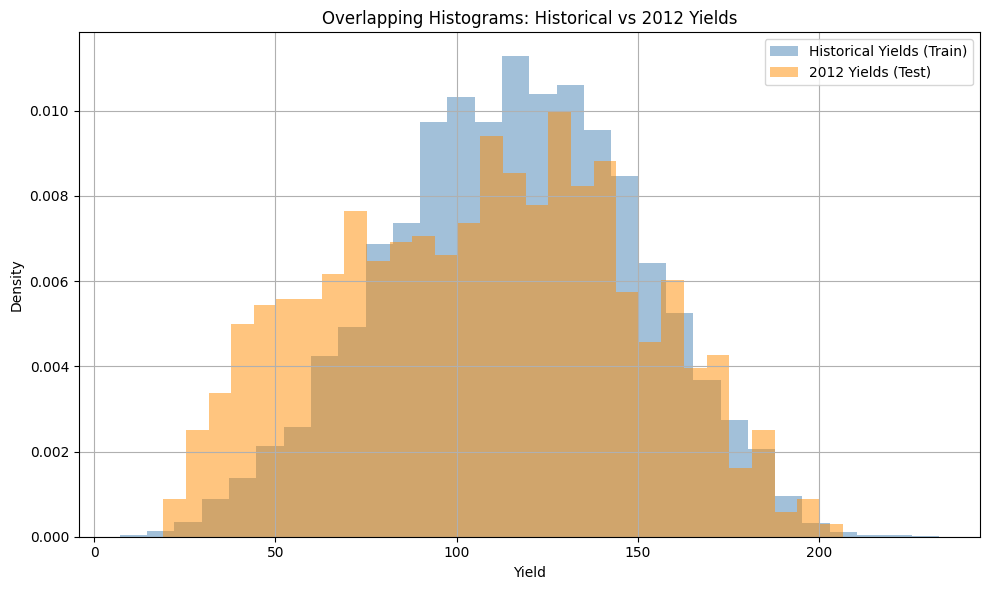

In [181]:
import matplotlib.pyplot as plt

# Historical yields (pre-2012)
train_yields = gridMET_augmented[gridMET_augmented['year'] < 2012]['yield'].dropna()

# Test yields (2012 full set)
test_yields = gridMET_augmented[gridMET_augmented['year'] == 2012]['yield'].dropna()

# Plot overlapping histograms
plt.figure(figsize=(10, 6))

plt.hist(train_yields, bins=30, alpha=0.5, label='Historical Yields (Train)', color='steelblue', density=True)
plt.hist(test_yields, bins=30, alpha=0.5, label='2012 Yields (Test)', color='darkorange', density=True)

plt.xlabel('Yield')
plt.ylabel('Density')
plt.title('Overlapping Histograms: Historical vs 2012 Yields')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Normal Distribution

Fitted Normal Distribution:
  Mean = 106.44, Std Dev = 40.94


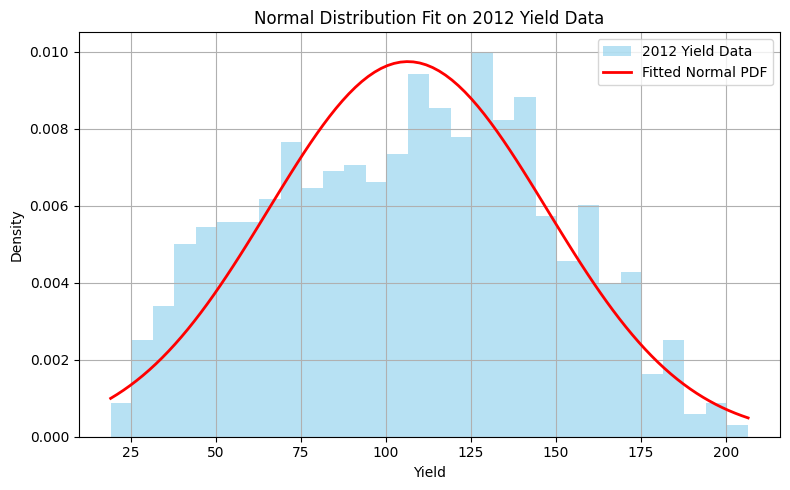

In [106]:
from scipy.stats import norm

# Extract 2012 yields
y_2012 = gridMET_augmented[gridMET_augmented['year'] == 2012]['yield'].dropna()

# Fit normal distribution
mu, std = norm.fit(y_2012)
print(f"Fitted Normal Distribution:\n  Mean = {mu:.2f}, Std Dev = {std:.2f}")

# Plot histogram of data
plt.figure(figsize=(8, 5))
count, bins, _ = plt.hist(y_2012, bins=30, density=True, alpha=0.6, color='skyblue', label='2012 Yield Data')

# Plot the fitted normal curve
x = np.linspace(min(bins), max(bins), 100)
pdf = norm.pdf(x, mu, std)
plt.plot(x, pdf, 'r-', lw=2, label='Fitted Normal PDF')

plt.title("Normal Distribution Fit on 2012 Yield Data")
plt.xlabel("Yield")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extreme Value Theory

In [14]:
gridMET_augmented.shape

(41267, 154)

In [5]:
from scipy.stats import genpareto

X_all = gridMET_augmented.drop(columns=['yield'])
y_all = gridMET_augmented['yield']

# ==== Extremeness Function ====
def extremeness(y): return -y  # low yields are extreme

# ==== Distribution Shifting ====
def shift_distribution(X, y, E, c = 0.25):
    e_scores = E(y)
    threshold = np.quantile(e_scores, 1 - c)
    mask = e_scores >= threshold
    return X[mask], y[mask]

X_shifted, y_shifted = shift_distribution(X_all, y_all, extremeness, c=0.25)

# ==== EVT Fit ====
e_scores = extremeness(y_all)
threshold_evt = np.percentile(e_scores, 95)
excesses = e_scores[e_scores > threshold_evt] - threshold_evt
c_evt, loc_evt, scale_evt = genpareto.fit(excesses)

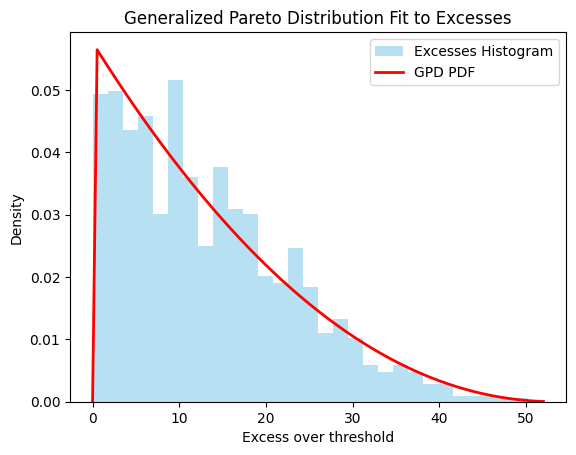

In [27]:
############### GPD fitted over Excess ###############

# Histogram of excesses
plt.hist(excesses, bins=30, density=True, alpha=0.6, color='skyblue', label='Excesses Histogram')

# Plot fitted GPD PDF
x = np.linspace(0, excesses.max(), 100)
gpd_pdf = genpareto.pdf(x, c_evt, loc_evt, scale_evt)
plt.plot(x, gpd_pdf, 'r-', lw=2, label='GPD PDF')

plt.xlabel('Excess over threshold')
plt.ylabel('Density')
plt.title('Generalized Pareto Distribution Fit to Excesses')
plt.legend()
plt.show()

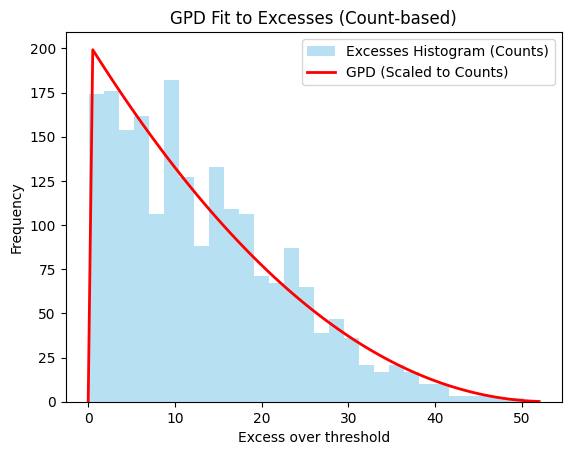

In [28]:
############### GPD fitted over Excess (Freq) ###############

# Plot histogram of excesses using raw counts
plt.hist(excesses, bins=30, density=False, alpha=0.6, color='skyblue', label='Excesses Histogram (Counts)')

# Plot fitted GPD PDF scaled to match histogram counts
x = np.linspace(0, excesses.max(), 100)
gpd_pdf = genpareto.pdf(x, c_evt, loc_evt, scale_evt)

# Scale PDF by total count and bin width to match histogram
bin_width = (excesses.max() - excesses.min()) / 30
gpd_pdf_scaled = gpd_pdf * len(excesses) * bin_width

plt.plot(x, gpd_pdf_scaled, 'r-', lw=2, label='GPD (Scaled to Counts)')

plt.xlabel('Excess over threshold')
plt.ylabel('Frequency')
plt.title('GPD Fit to Excesses (Count-based)')
plt.legend()
plt.show()

In [10]:
train_df = gridMET_augmented[gridMET_augmented['year'] < 2012]
test_df = gridMET_augmented[gridMET_augmented['year'] == 2012]

X_train_all = train_df.drop(columns=['yield'])
y_train_all = train_df['yield']

X_test = test_df.drop(columns=['yield'])
y_test = test_df['yield']  

X_extreme, y_extreme = shift_distribution(X_train_all, y_train_all, extremeness, c=0.25)
print("Extremeness calculated")

scaler = StandardScaler()
X_extreme_scaled = scaler.fit_transform(X_extreme)
X_test_scaled = scaler.transform(X_test)

model = Ridge(alpha=100.0)
model.fit(X_extreme_scaled, y_extreme)

y_pred_2012 = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_2012))
r2 = r2_score(y_test, y_pred_2012)

print(f"2012 RMSE: {rmse:.3f}, R²: {r2:.3f}")

Extremeness calculated
2012 RMSE: 57.677, R²: -0.985


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [12]:
X_shifted

,id2,year,tmmx_mean,rmax_mean,vs_mean,bi_mean,sph_mean,fm1000_mean,srad_mean,erc_mean,...,rmin_mean,pr_mean,fm100_mean,etr_mean,pet_mean,tmmn_mean,th_mean,yield_prev_year,yield_5yr_mean,yield_trend_pred
0,112,1983,300.639303,94.097118,3.815043,16.742324,0.010995,18.575281,237.410359,23.975018,...,43.098195,3.087683,16.348298,6.133326,4.715547,286.973014,179.288948,73.0,85.20,100.333333
1,119,1983,302.029915,93.633880,3.329415,16.203583,0.011223,17.760443,235.748185,26.791561,...,39.927190,2.862513,15.734554,6.153508,4.759533,288.333050,173.578359,114.0,88.20,159.666667
2,120,1983,301.208597,93.061567,3.651784,15.083636,0.010881,18.147775,234.792130,24.919567,...,41.504952,3.205091,15.952987,6.112511,4.695394,287.389697,190.374372,90.0,95.00,118.000000
3,124,1983,302.114678,92.225551,3.264911,16.708450,0.011364,17.480686,236.101303,27.773810,...,40.182311,2.812619,15.429192,6.150397,4.769276,289.102773,176.311718,86.0,96.80,125.666667
4,136,1983,302.057880,93.499875,3.533090,16.377721,0.011257,17.874337,236.271565,26.480215,...,40.040312,2.900006,15.768010,6.294178,4.834535,288.533186,176.063265,80.0,96.00,115.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41108,2162,2018,301.979452,87.286318,4.207101,27.051042,0.011390,16.779250,242.009211,31.860149,...,38.683940,3.748476,14.722315,7.180705,5.386360,289.196443,123.430744,32.6,143.98,78.490412
41109,2171,2018,301.606470,87.861274,4.480122,26.960131,0.011550,16.824713,240.218841,31.188998,...,41.032269,3.729964,14.923186,7.053747,5.292663,289.172608,130.491034,53.0,146.66,72.827773
41112,2187,2018,301.914825,87.987025,4.040367,26.032154,0.011655,16.568385,240.388517,31.969977,...,40.775959,3.213601,14.820005,6.849683,5.199401,289.399991,126.212063,66.2,174.30,51.685021
41129,2381,2018,295.712309,88.428138,4.241728,27.083741,0.007350,16.427738,227.585186,33.502913,...,34.863466,2.238392,14.324429,6.010945,4.438022,281.564626,163.310309,74.9,107.12,87.394618


In [14]:
# ==== Config ====
noise_dim = 32
hidden_dim = 128
batch_size = 128
epochs = 1000
λ_ext = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==== Models ====
class Generator(nn.Module):
    def __init__(self, noise_dim, cond_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, z, e): return self.net(torch.cat([z, e], dim=1))

class Discriminator(nn.Module):
    def __init__(self, input_dim, cond_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + cond_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )
    def forward(self, x, e): return self.net(torch.cat([x, e], dim=1))

G = Generator(noise_dim, 1, X_all.shape[1]).to(device)
D = Discriminator(X_all.shape[1], 1).to(device)

# ==== Loss + Optimizers ====
bce_loss = nn.BCELoss()
g_optimizer = optim.Adam(G.parameters(), lr=1e-4)
d_optimizer = optim.Adam(D.parameters(), lr=1e-4)

# ==== Dataset ====
X_tensor = torch.tensor(X_shifted.values, dtype=torch.float32)
y_tensor = torch.tensor(y_shifted.values, dtype=torch.float32)
e_tensor = extremeness(y_tensor).unsqueeze(1)

train_loader = DataLoader(TensorDataset(X_tensor, e_tensor), batch_size=batch_size, shuffle=True)

# ==== Extremeness Loss (L_ext) ====
def l_ext_loss(X_gen, target_e, E_func=extremeness):
    yield_pred = -E_func(X_gen[:, -1])  # crude: use last feature as proxy yield
    return torch.mean(torch.abs(yield_pred - target_e.squeeze()) / target_e.squeeze())

# ==== Training Loop ====
for epoch in range(epochs):
    for X_batch, e_batch in train_loader:
        X_batch = X_batch.to(device)
        e_batch = e_batch.to(device)

        # === Train Discriminator ===
        z = torch.randn(X_batch.size(0), noise_dim).to(device)
        fake_X = G(z, e_batch)
        real_label = torch.ones(X_batch.size(0), 1).to(device)
        fake_label = torch.zeros(X_batch.size(0), 1).to(device)

        d_real = D(X_batch, e_batch)
        d_fake = D(fake_X.detach(), e_batch)

        d_loss = bce_loss(d_real, real_label) + bce_loss(d_fake, fake_label)
        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # === Train Generator ===
        z = torch.randn(X_batch.size(0), noise_dim).to(device)
        fake_X = G(z, e_batch)
        d_fake = D(fake_X, e_batch)
        adv_loss = bce_loss(d_fake, real_label)
        ext_loss = l_ext_loss(fake_X, e_batch)
        g_loss = adv_loss + λ_ext * ext_loss

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f} | L_ext: {ext_loss.item():.4f}")

Epoch 100/1000 | D Loss: 1.0417 | G Loss: -81165.6250 | L_ext: -8126.5625
Epoch 200/1000 | D Loss: 0.0000 | G Loss: -570428.3750 | L_ext: -57052.8398
Epoch 300/1000 | D Loss: 0.0000 | G Loss: -1793918.7500 | L_ext: -179401.8750
Epoch 400/1000 | D Loss: 0.0000 | G Loss: -4078561.0000 | L_ext: -407866.0938
Epoch 500/1000 | D Loss: 0.0000 | G Loss: -7765732.5000 | L_ext: -776583.2500
Epoch 600/1000 | D Loss: 0.0000 | G Loss: -13164440.0000 | L_ext: -1316454.0000
Epoch 700/1000 | D Loss: 0.0000 | G Loss: -20672714.0000 | L_ext: -2067281.3750
Epoch 800/1000 | D Loss: 0.0000 | G Loss: -30529870.0000 | L_ext: -3052997.0000
Epoch 900/1000 | D Loss: 0.0000 | G Loss: -43142760.0000 | L_ext: -4314286.0000
Epoch 1000/1000 | D Loss: 0.0000 | G Loss: -58780756.0000 | L_ext: -5878085.5000


In [15]:
def sample_extreme_e(n_samples, τ, c_evt, scale_evt, threshold_evt):
    e_val = genpareto.ppf(1 - τ, c_evt, loc=0, scale=scale_evt) + threshold_evt
    return torch.full((n_samples, 1), e_val, dtype=torch.float32)

def generate_extreme_samples(generator, n_samples=100, τ=0.01):
    generator.eval()
    z = torch.randn(n_samples, noise_dim).to(device)
    e = sample_extreme_e(n_samples, τ, c_evt, scale_evt, threshold_evt).to(device)
    with torch.no_grad():
        x_gen = generator(z, e)
    return x_gen.cpu().numpy()

X_extreme_synthetic = generate_extreme_samples(G, n_samples=200, τ=0.01)

In [17]:
extreme_mask = extremeness(y_all) >= np.quantile(extremeness(y_all), 0.99)
X_real_extreme = X_all[extreme_mask]
X_extreme_synthetic_df = pd.DataFrame(X_extreme_synthetic, columns=X_all.columns)

In [18]:
X_extreme_synthetic_df

,id2,year,tmmx_mean,rmax_mean,vs_mean,bi_mean,sph_mean,fm1000_mean,srad_mean,erc_mean,...,rmin_mean,pr_mean,fm100_mean,etr_mean,pet_mean,tmmn_mean,th_mean,yield_prev_year,yield_5yr_mean,yield_trend_pred
0,-23149.050781,3379444.00,303641.12500,-812212.2500,-89498.117188,79368.843750,-400819.71875,259039.078125,-620979.1875,-237662.781250,...,-78814.968750,-524587.50000,-556605.5000,34806.054688,-236908.234375,1058357.500,-673842.1875,-108661.203125,-65009.960938,-107148576.0
1,-23179.589844,3383974.25,304048.81250,-813301.5625,-89619.421875,79475.578125,-401357.12500,259386.234375,-621811.3125,-237981.187500,...,-78920.328125,-525289.81250,-557351.3750,34853.691406,-237226.125000,1059777.250,-674745.3125,-108807.414062,-65097.210938,-107292416.0
2,-23181.689453,3384140.00,304063.65625,-813339.9375,-89623.085938,79479.937500,-401376.34375,259399.843750,-621841.5000,-237993.296875,...,-78924.726562,-525315.62500,-557379.3125,34855.136719,-237237.203125,1059829.500,-674776.9375,-108812.843750,-65100.175781,-107297408.0
3,-23148.160156,3379496.25,303645.87500,-812225.5625,-89500.875000,79370.015625,-400827.00000,259042.750000,-620988.8125,-237665.515625,...,-78815.515625,-524594.87500,-556613.2500,34807.105469,-236913.125000,1058374.250,-673853.2500,-108663.828125,-65010.789062,-107150576.0
4,-23127.732422,3376375.00,303365.59375,-811474.7500,-89417.226562,79296.765625,-400455.87500,258803.906250,-620415.5625,-237447.125000,...,-78743.046875,-524110.56250,-556100.1875,34774.851562,-236693.296875,1057397.000,-673230.0000,-108562.804688,-64950.855469,-107051368.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-23157.496094,3380824.25,303765.43750,-812543.9375,-89535.375000,79401.335938,-400984.18750,259144.828125,-621232.8125,-237759.859375,...,-78846.718750,-524800.68750,-556832.5000,34820.562500,-237005.375000,1058790.125,-674117.3125,-108705.718750,-65036.222656,-107192568.0
196,-23173.027344,3382619.00,303927.15625,-812973.4375,-89582.171875,79444.757812,-401194.68750,259283.562500,-621562.5625,-237887.375000,...,-78889.750000,-525080.31250,-557130.1250,34839.460938,-237129.109375,1059353.375,-674473.0625,-108763.296875,-65070.839844,-107248864.0
197,-23137.509766,3377542.50,303471.25000,-811754.5625,-89448.382812,79325.320312,-400592.84375,258894.234375,-620629.1250,-237529.984375,...,-78771.148438,-524292.56250,-556293.5000,34786.859375,-236773.937500,1057763.750,-673461.3750,-108600.203125,-64973.425781,-107088104.0
198,-23135.513672,3377284.75,303447.59375,-811693.8750,-89441.859375,79318.851562,-400563.03125,258873.953125,-620583.2500,-237511.546875,...,-78764.351562,-524252.71875,-556250.0000,34784.386719,-236756.578125,1057683.375,-673411.5625,-108592.375000,-64968.878906,-107080144.0


In [25]:
######################################################################################################
############################ Interaction and Interaction-less Regression ############################
######################################################################################################

# ==================== 2. Modeling ====================

# Define final feature columns (exclude ID, year, and target)
non_model_cols = ['id2', 'year', 'yield']
X_all = gridMET_augmented.drop(columns=non_model_cols)
y_all = gridMET_augmented['yield']

# Time-based split
train_mask = gridMET_augmented['year'] < 2010
test_mask = gridMET_augmented['year'].between(2010, 2018)

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---------- (a) Ridge Regression (No Interactions) ----------
model_plain = Ridge(alpha=1000.0)
model_plain.fit(X_train_scaled, y_train)
y_pred_plain = model_plain.predict(X_test_scaled)
r2_plain = r2_score(y_test, y_pred_plain)
rmse_plain = np.sqrt(mean_squared_error(y_test, y_pred_plain))

print("Linear Regression WITHOUT Interaction Terms:")
print(f"R² Score: {r2_plain:.4f}")
print(f"RMSE: {rmse_plain:.4f}\n")

# ---------- (b) Ridge Regression (With Interactions) ----------
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

model_interact = Ridge(alpha=1000.0)
model_interact.fit(X_train_poly, y_train)
y_pred_interact = model_interact.predict(X_test_poly)
r2_interact = r2_score(y_test, y_pred_interact)
rmse_interact = np.sqrt(mean_squared_error(y_test, y_pred_interact))

print("Linear Regression WITH Interaction Terms:")
print(f"R² Score: {r2_interact:.4f}")
print(f"RMSE: {rmse_interact:.4f}")

/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


Linear Regression WITHOUT Interaction Terms:
R² Score: 0.6361
RMSE: 23.0271



/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


Linear Regression WITH Interaction Terms:
R² Score: 0.2958
RMSE: 32.0344


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

In [10]:
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression

# 1. Remove near-constant features
vt = VarianceThreshold(threshold=1e-5)
X_train_raw = vt.fit_transform(X_all[train_mask])
X_test_raw = vt.transform(X_all[test_mask])
y_train = y_all[train_mask]
y_test = y_all[test_mask]

# 2. Robust scaling
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# Optional: reduce dimension before poly
selector = SelectKBest(f_regression, k=10)
X_train_reduced = selector.fit_transform(X_train_scaled, y_train)
X_test_reduced = selector.transform(X_test_scaled)

# 3. Add interactions
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reduced)
X_test_poly = poly.transform(X_test_reduced)

# 4. Fit ridge regression
model = Ridge(alpha=1000.0)
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

# 5. Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Interaction Ridge Model")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Interaction Ridge Model
R² Score: 0.5439
RMSE: 25.7812


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by 

In [13]:
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# ---------------- Matern 3/2 Kernel Function ----------------
def apply_matern32_matrix(X, sigma_f=1.0, sigma_l=1.0):
    abs_X = np.abs(X)
    sqrt3 = np.sqrt(3)
    return sigma_f**2 * (1 + sqrt3 * abs_X / sigma_l) * np.exp(-sqrt3 * abs_X / sigma_l)

# ---------------- Data Setup ----------------
non_feature_cols = ['id2', 'year', 'yield']
X_all = gridMET_augmented.drop(columns=non_feature_cols)
y_all = gridMET_augmented['yield']

# Time-based split
train_mask = gridMET_augmented['year'] < 2010
test_mask = gridMET_augmented['year'].between(2010, 2018)

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

# ---------------- Standardize ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---------------- Polynomial Expansion (Degree 2) ----------------
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Identify original + new features
n_orig = X_train_scaled.shape[1]
X_train_orig = X_train_scaled
X_test_orig = X_test_scaled
X_train_extra = X_train_poly[:, n_orig:]
X_test_extra = X_test_poly[:, n_orig:]

# ---------------- Apply Matern Kernel (Vectorized) ----------------
X_train_extra_k = apply_matern32_matrix(X_train_extra)
X_test_extra_k = apply_matern32_matrix(X_test_extra)

# Combine final features: original + kernelized interaction terms
X_train_final = np.hstack([X_train_orig, X_train_extra_k])
X_test_final = np.hstack([X_test_orig, X_test_extra_k])

print(f"Final feature shape — Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# ---------------- Ridge Regression ----------------
model = Ridge(alpha=100.0)
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

# ---------------- Evaluation ----------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Ridge Regression with Matern 3/2 Interaction Terms ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

Final feature shape — Train: (32148, 11627), Test: (9119, 11627)


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b



=== Ridge Regression with Matern 3/2 Interaction Terms ===
R² Score: 0.5808
RMSE: 24.7152


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: i

In [18]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import f_regression

# --- Matern 3/2 Kernel Function ---
def apply_matern32_matrix(X, sigma_f=1.0, sigma_l=1.0):
    abs_X = np.abs(X)
    sqrt3 = np.sqrt(3)
    return sigma_f**2 * (1 + sqrt3 * abs_X / sigma_l) * np.exp(-sqrt3 * abs_X / sigma_l)

# ---------------- Data Setup ----------------
non_feature_cols = ['id2', 'year', 'yield']
X_all = gridMET_augmented.drop(columns=non_feature_cols)
y_all = gridMET_augmented['yield']

# Time-based split
train_mask = gridMET_augmented['year'] < 2010
test_mask = gridMET_augmented['year'].between(2010, 2018)

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

# ---------------- Standardize ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# ---------------- Polynomial Expansion ----------------
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_feature_names = poly.get_feature_names_out(X_all.columns)

# Separate original and interaction/squared terms
n_orig = X_train_scaled.shape[1]
X_train_orig = X_train_scaled
X_test_orig = X_test_scaled
X_train_inter = X_train_poly[:, n_orig:]
X_test_inter = X_test_poly[:, n_orig:]
inter_names = poly_feature_names[n_orig:]

# ---------------- Feature Selection (Top 30 Interactions) ----------------
f_scores, _ = f_regression(X_train_inter, y_train)
top_k_idx = np.argsort(f_scores)[-20:]  # indices of top 30
X_train_top = X_train_inter[:, top_k_idx]
X_test_top = X_test_inter[:, top_k_idx]
top_feature_names = [inter_names[i] for i in top_k_idx]

print("\nTop 30 selected interaction/squared features:")
for name in top_feature_names:
    print(f" - {name}")

# ---------------- Kernelize Top Interactions ----------------
X_train_k = apply_matern32_matrix(X_train_top)
X_test_k = apply_matern32_matrix(X_test_top)

# ---------------- Combine Final Feature Set ----------------
X_train_final = np.hstack([X_train_orig, X_train_k])
X_test_final = np.hstack([X_test_orig, X_test_k])

print(f"\nFinal feature shape — Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# ---------------- Ridge Regression ----------------
model = Ridge(alpha=100.0)
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

# ---------------- Evaluation ----------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== Ridge Regression with Top 30 Matern 3/2 Interaction Terms ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Top 30 selected interaction/squared features:
 - sph_skew pet_std
 - rmin_25q yield_trend_pred
 - bi_50q yield_mean
 - bi_std yield_min
 - rmax_min yield_mean
 - etr_std yield_mean
 - bi_std yield_prev_year
 - sph_std yield_trend_pred
 - bi_max yield_mean
 - rmin_75q yield_mean
 - rmax_std th_std
 - rmax_std yield_trend_pred
 - pr_std th_75q
 - bi_std yield_trend_pred
 - th_75q yield_std
 - bi_std yield_mean
 - rmin_min yield_mean
 - rmin_mean yield_mean
 - rmin_50q yield_mean
 - rmin_25q yield_mean

Final feature shape — Train: (32148, 171), Test: (9119, 171)

=== Ridge Regression with Top 30 Matern 3/2 Interaction Terms ===
R² Score: 0.6371
RMSE: 22.9974


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by 

In [25]:
# =========================
# Define kernel functions
# =========================
def linear_kernel(x, **kwargs): return x ** 2

def squared_exp_kernel(x, sigma_f=1.0, sigma_l=1.0, **kwargs):
    return sigma_f**2 * np.exp(-0.5 * (x / sigma_l)**2)

def exponential_kernel(x, sigma_f=1.0, sigma_l=1.0, **kwargs):
    return sigma_f**2 * np.exp(-np.abs(x) / sigma_l)

def matern32_kernel(x, sigma_f=1.0, sigma_l=1.0, **kwargs):
    sqrt3 = np.sqrt(3)
    return sigma_f**2 * (1 + sqrt3 * np.abs(x)/sigma_l) * np.exp(-sqrt3 * np.abs(x)/sigma_l)

def matern52_kernel(x, sigma_f=1.0, sigma_l=1.0, **kwargs):
    sqrt5 = np.sqrt(5)
    r = np.abs(x)
    return sigma_f**2 * (1 + sqrt5*r/sigma_l + 5*r**2/(3*sigma_l**2)) * np.exp(-sqrt5*r/sigma_l)

def rational_quad_kernel(x, sigma_f=1.0, sigma_l=1.0, theta=1.0, **kwargs):
    return sigma_f**2 * (1 + x**2 / (2 * theta * sigma_l**2))**(-theta)

kernel_functions = {
    'linear': linear_kernel,
    'sq_exp': squared_exp_kernel,
    'exp': exponential_kernel,
    'matern32': matern32_kernel,
    'matern52': matern52_kernel,
    'rq': rational_quad_kernel
}

# =========================
# Select kernel type here:
kernel_type = 'linear'  # Change to 'linear', 'sq_exp', etc.
# =========================

kernel_fn = kernel_functions[kernel_type]

# =========================
# Data Setup
# =========================
non_feature_cols = ['id2', 'year', 'yield']
X_all = gridMET_augmented.drop(columns=non_feature_cols)
y_all = gridMET_augmented['yield']

# Time-based split
train_mask = gridMET_augmented['year'] < 2010
test_mask = gridMET_augmented['year'].between(2010, 2018)

X_train_raw = X_all[train_mask]
y_train = y_all[train_mask]
X_test_raw = X_all[test_mask]
y_test = y_all[test_mask]

# =========================
# Standardize
# =========================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# =========================
# Polynomial Expansion
# =========================
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
poly_feature_names = poly.get_feature_names_out(X_all.columns)

n_orig = X_train_scaled.shape[1]
X_train_inter = X_train_poly[:, n_orig:]
X_test_inter = X_test_poly[:, n_orig:]
inter_names = poly_feature_names[n_orig:]

# =========================
# Top-K Interaction Terms
# =========================
f_scores, _ = f_regression(X_train_inter, y_train)
top_k_idx = np.argsort(f_scores)[-30:]
X_train_top = X_train_inter[:, top_k_idx]
X_test_top = X_test_inter[:, top_k_idx]
top_feature_names = [inter_names[i] for i in top_k_idx]

print(f"\nTop 30 selected features ({kernel_type} kernel):")
for name in top_feature_names:
    print(f" - {name}")

# =========================
# Kernelize Interaction Terms
# =========================
X_train_kernel = kernel_fn(X_train_top)
X_test_kernel = kernel_fn(X_test_top)

# =========================
# Final Feature Matrix
# =========================
X_train_final = np.hstack([X_train_scaled, X_train_kernel])
X_test_final = np.hstack([X_test_scaled, X_test_kernel])

print(f"\nFinal feature shape — Train: {X_train_final.shape}, Test: {X_test_final.shape}")

# =========================
# Ridge Regression
# =========================
model = Ridge(alpha=100.0)
model.fit(X_train_final, y_train)
y_pred = model.predict(X_test_final)

# =========================
# Evaluation
# =========================
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n=== Ridge Regression with Top 30 Kernelized ({kernel_type}) Interactions ===")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")


Top 30 selected features (linear kernel):
 - pr_std th_std
 - bi_mean yield_mean
 - pet_std yield_mean
 - bi_std th_std
 - vpd_std yield_mean
 - rmax_std yield_mean
 - etr_std yield_trend_pred
 - sph_skew etr_std
 - bi_75q yield_mean
 - bi_max yield_trend_pred
 - sph_skew pet_std
 - rmin_25q yield_trend_pred
 - bi_50q yield_mean
 - bi_std yield_min
 - rmax_min yield_mean
 - etr_std yield_mean
 - bi_std yield_prev_year
 - sph_std yield_trend_pred
 - bi_max yield_mean
 - rmin_75q yield_mean
 - rmax_std th_std
 - rmax_std yield_trend_pred
 - pr_std th_75q
 - bi_std yield_trend_pred
 - th_75q yield_std
 - bi_std yield_mean
 - rmin_min yield_mean
 - rmin_mean yield_mean
 - rmin_50q yield_mean
 - rmin_25q yield_mean

Final feature shape — Train: (32148, 181), Test: (9119, 181)

=== Ridge Regression with Top 30 Kernelized (linear) Interactions ===
R² Score: 0.6336
RMSE: 23.1058


/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/guptsh/shrey_env/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by 